# Mérési notebook
---
# **3. mérési fázis**. A	Modellek tesztelése teljes tanítással.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

---

## NORMALIZÁLT MÁTRIXOK GENERÁLÁSA

---



In [ ]:
# 🧰 Alapcsomagok
!pip install -q timm scikit-learn scikit-plot

# 🖼️ matplotlib + seaborn (ha valami hiányzik)
!pip install -q matplotlib seaborn

# 📁 Google Drive csatolása
from google.colab import drive
drive.mount('/content/drive')

# 📦 Kitömörítés, ha szükséges
import zipfile, os

diploma_path = "/content/drive/MyDrive/diplomamunka"
dataset_zip = os.path.join(diploma_path, "imagenet_splitted_db.zip")
dataset_dir = "/content/imagenet_splitted_db"

if not os.path.exists(dataset_dir):
    with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
        zip_ref.extractall("/content")
    print("✅ Kicsomagolva:", dataset_dir)
else:
    print("✅ Már ki van csomagolva:", dataset_dir)

# ⚙️ GPU ellenőrzés
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📡 Aktív eszköz: {device}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Kicsomagolva: /content/imagenet_splitted_db
📡 Aktív eszköz: cuda


Eszköz: cuda
📚 Kategóriák száma: 114

✨ Modell: resnet50


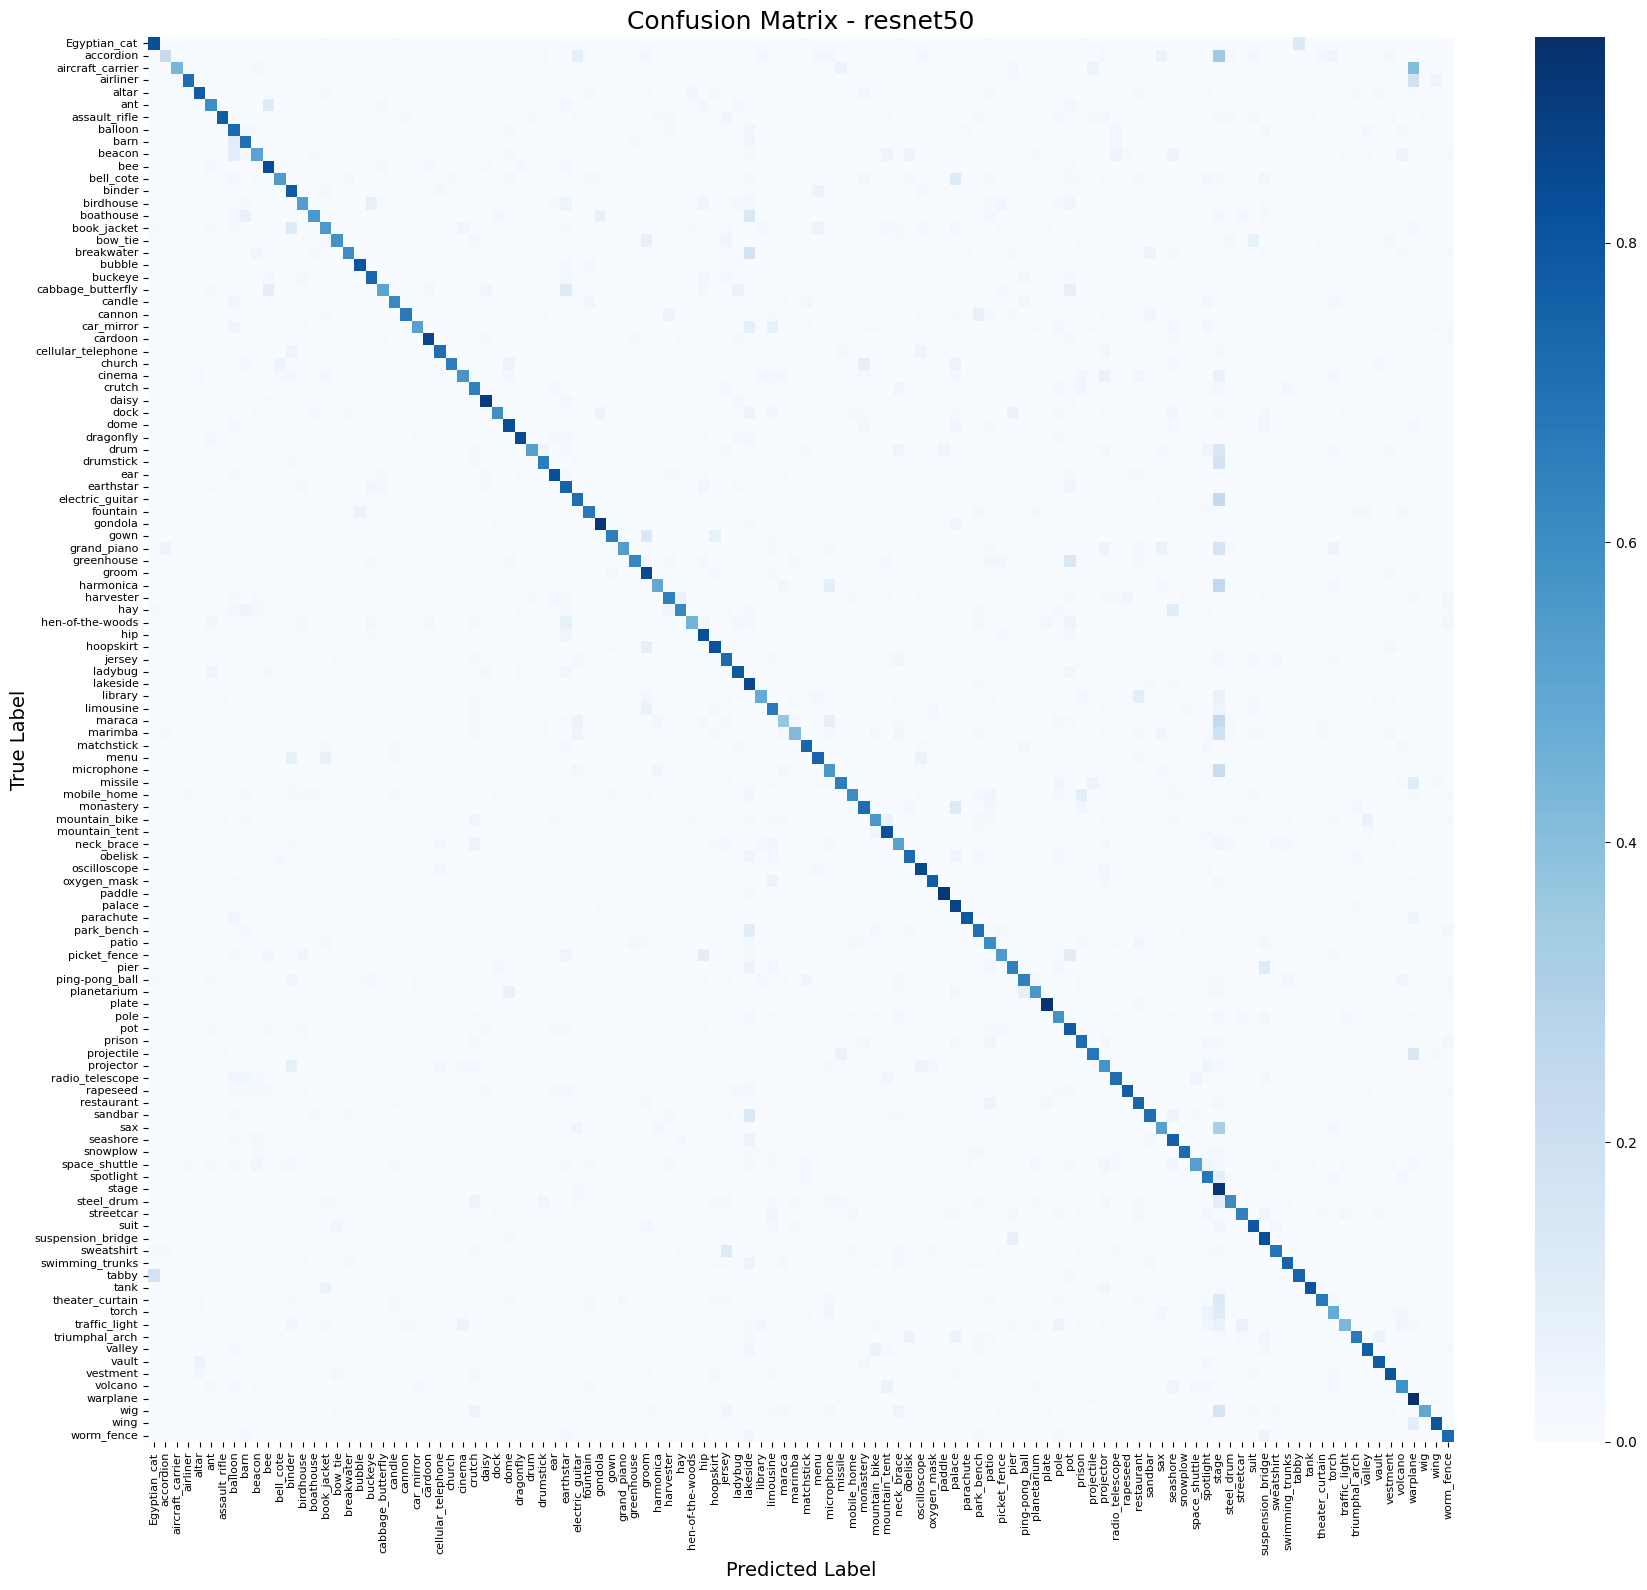


✨ Modell: densenet121


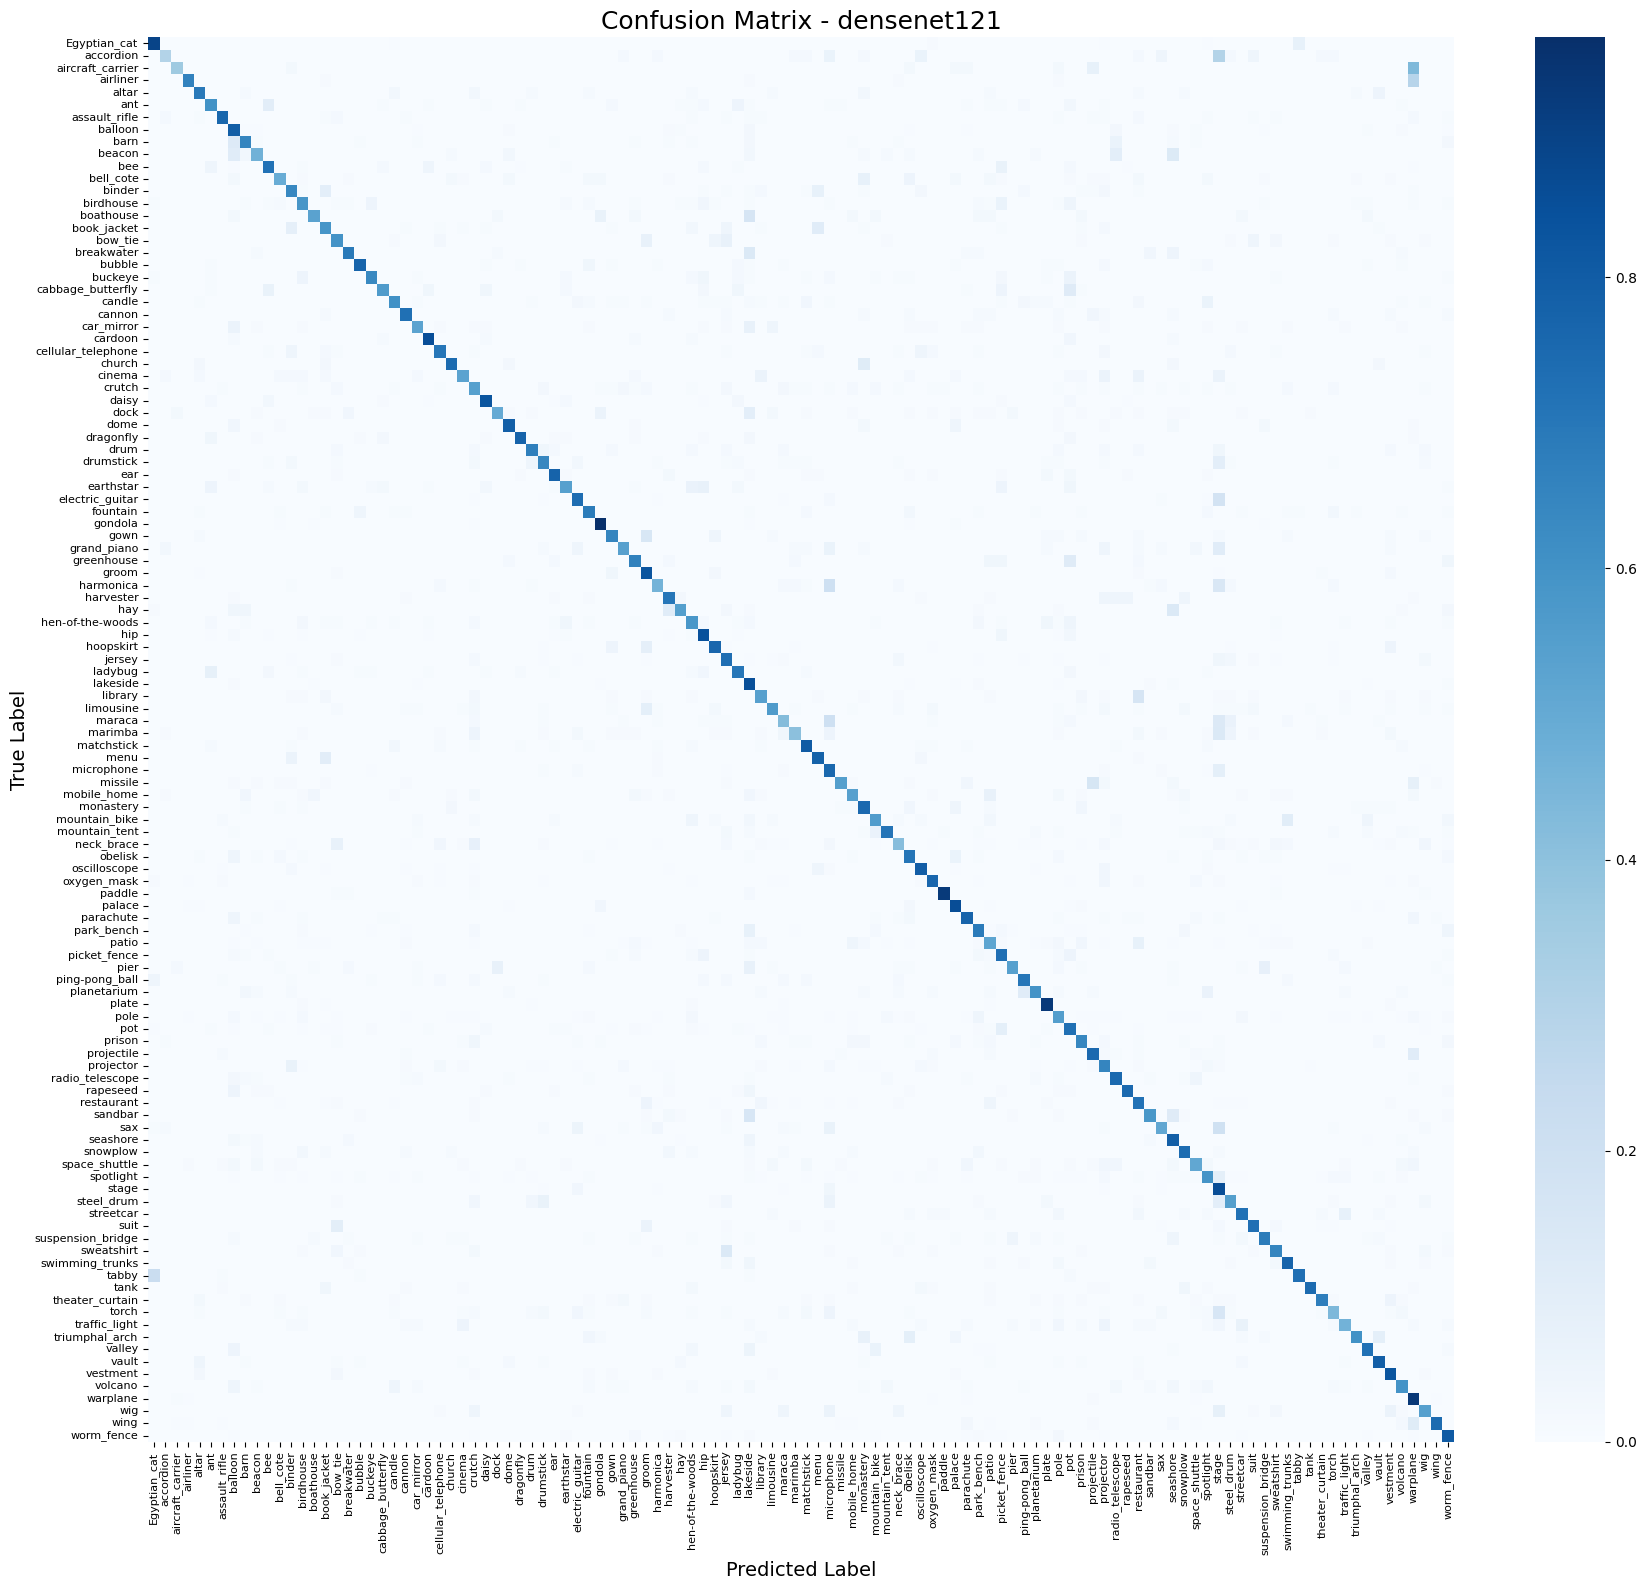


✨ Modell: efficientnet_b0


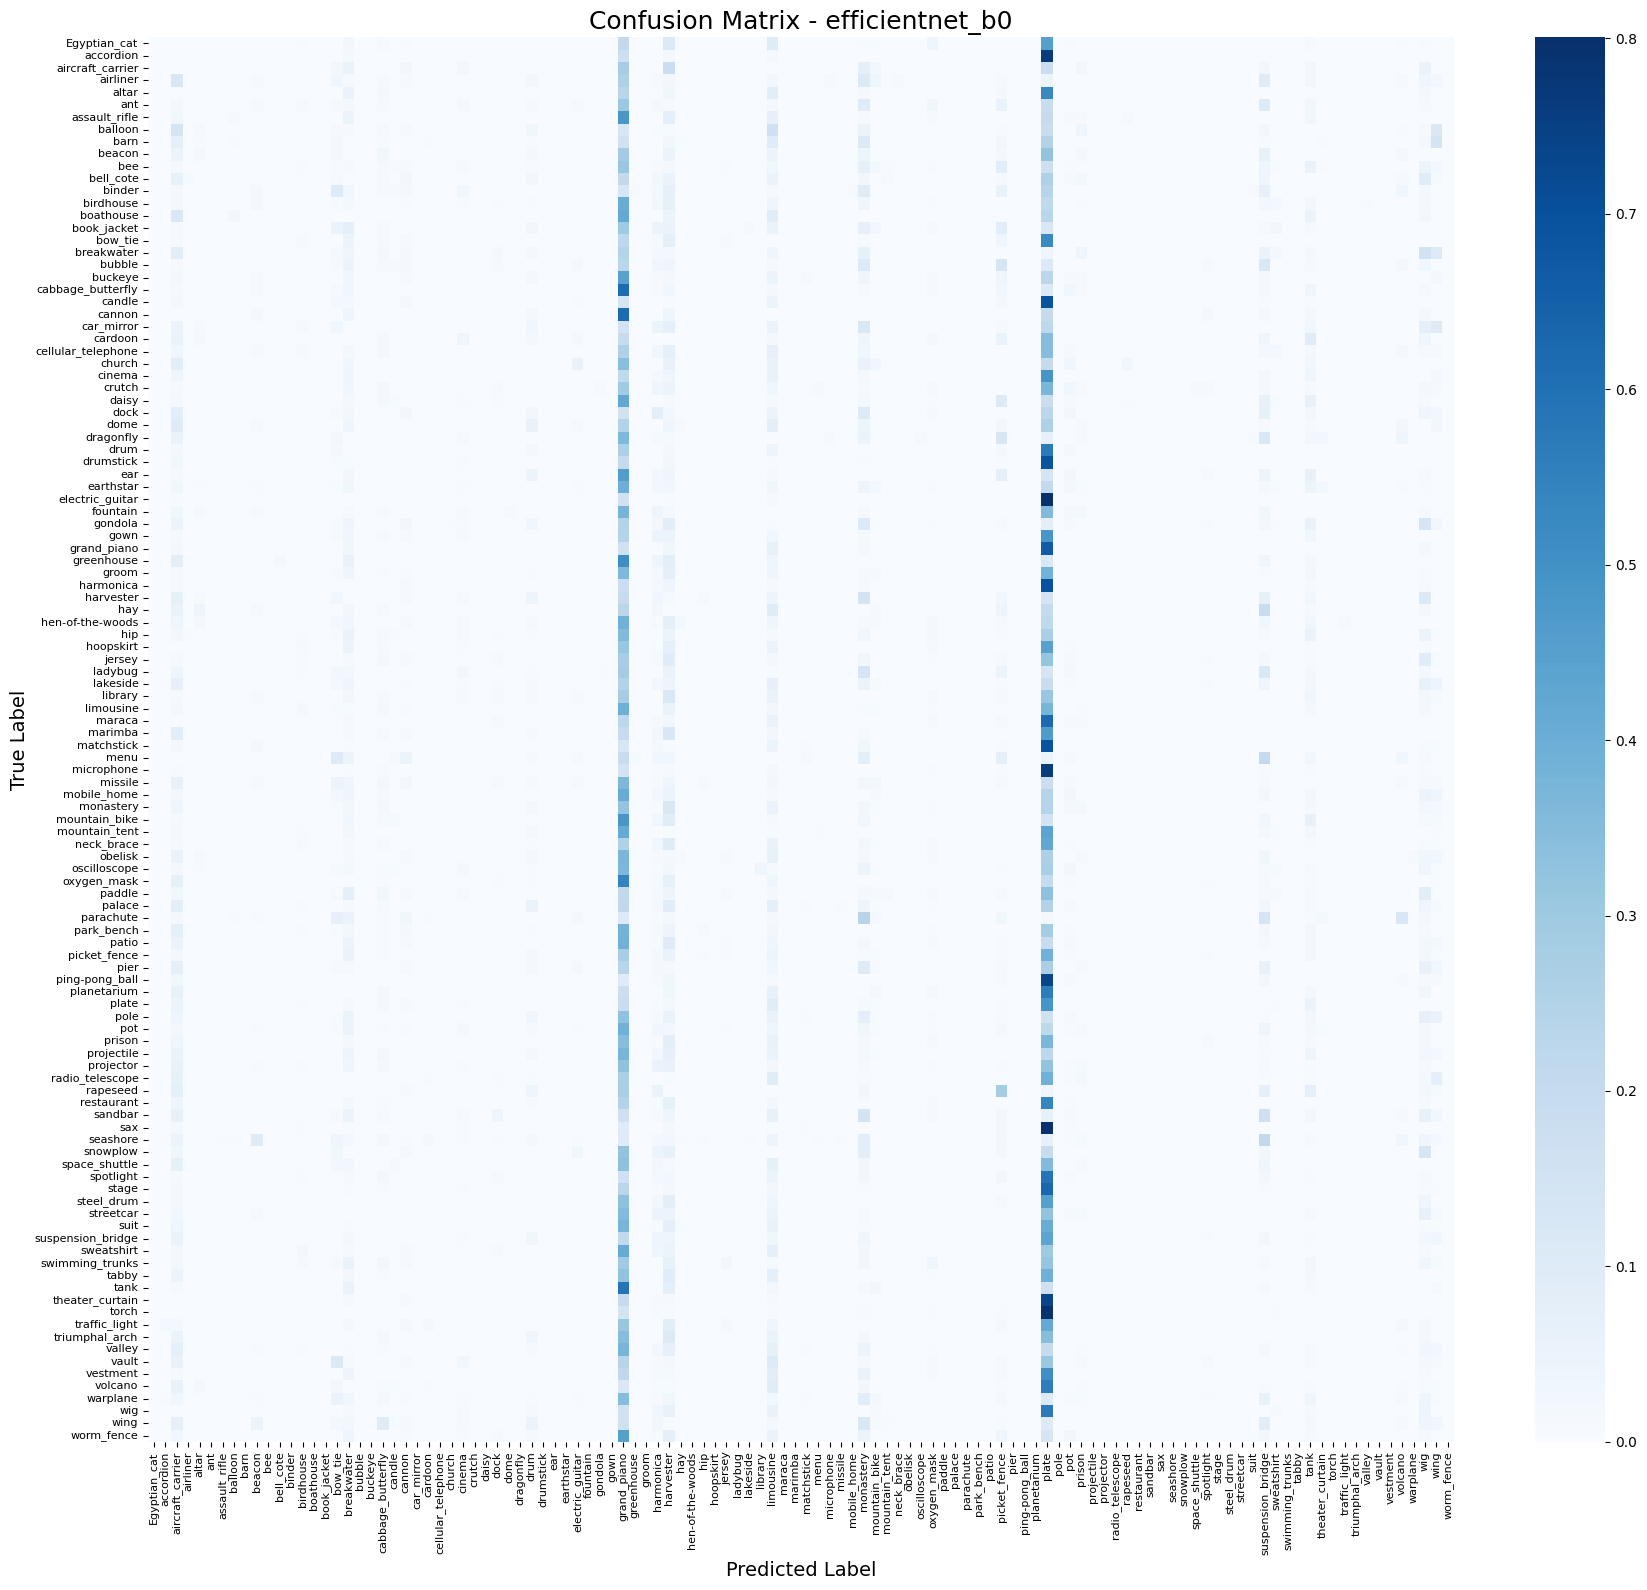


✨ Modell: convnext_tiny


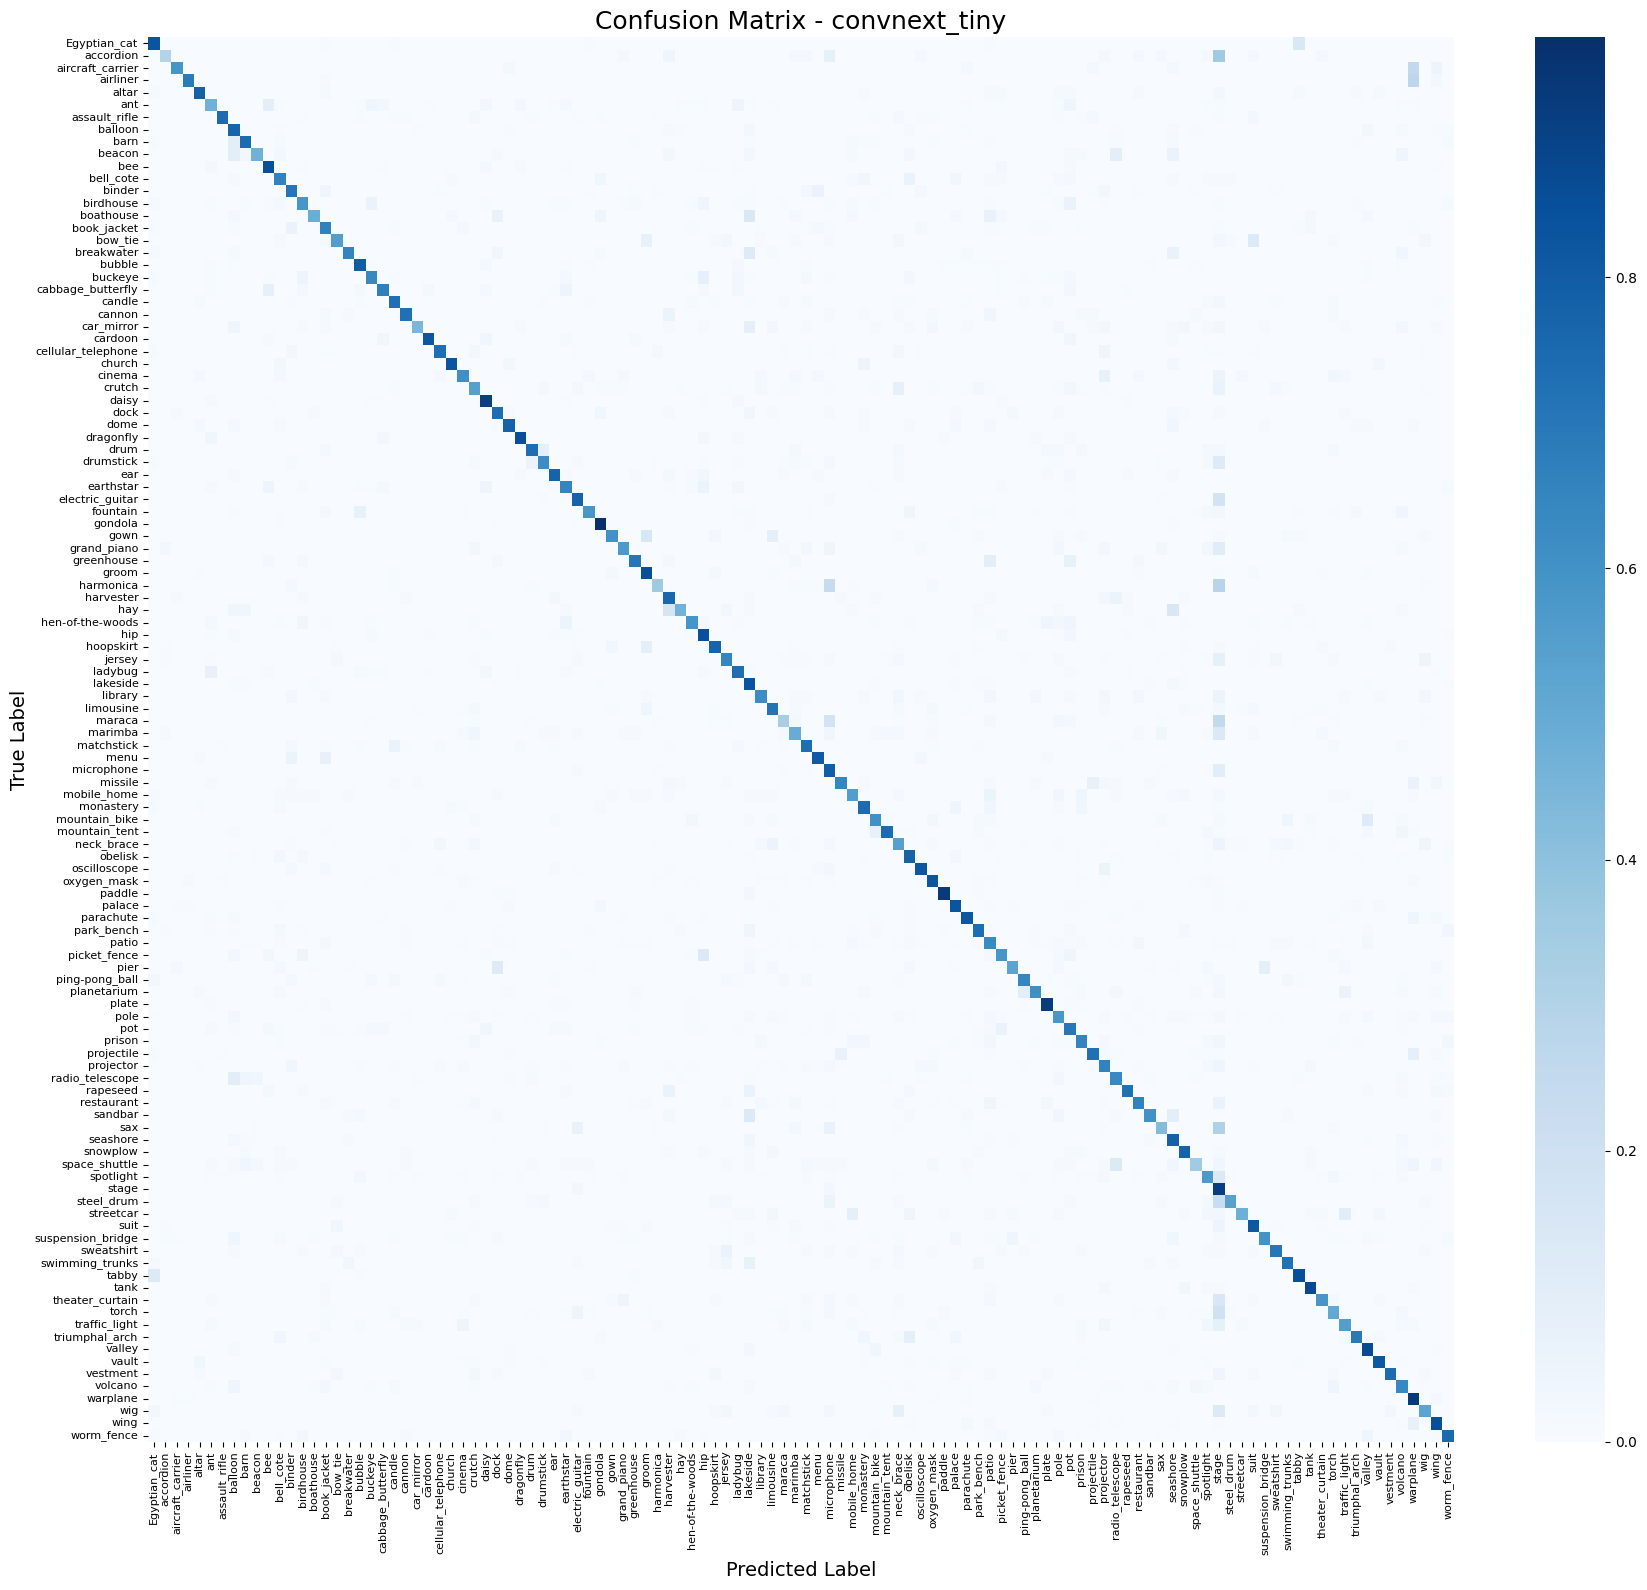


✨ Modell: vit_base_patch16_224


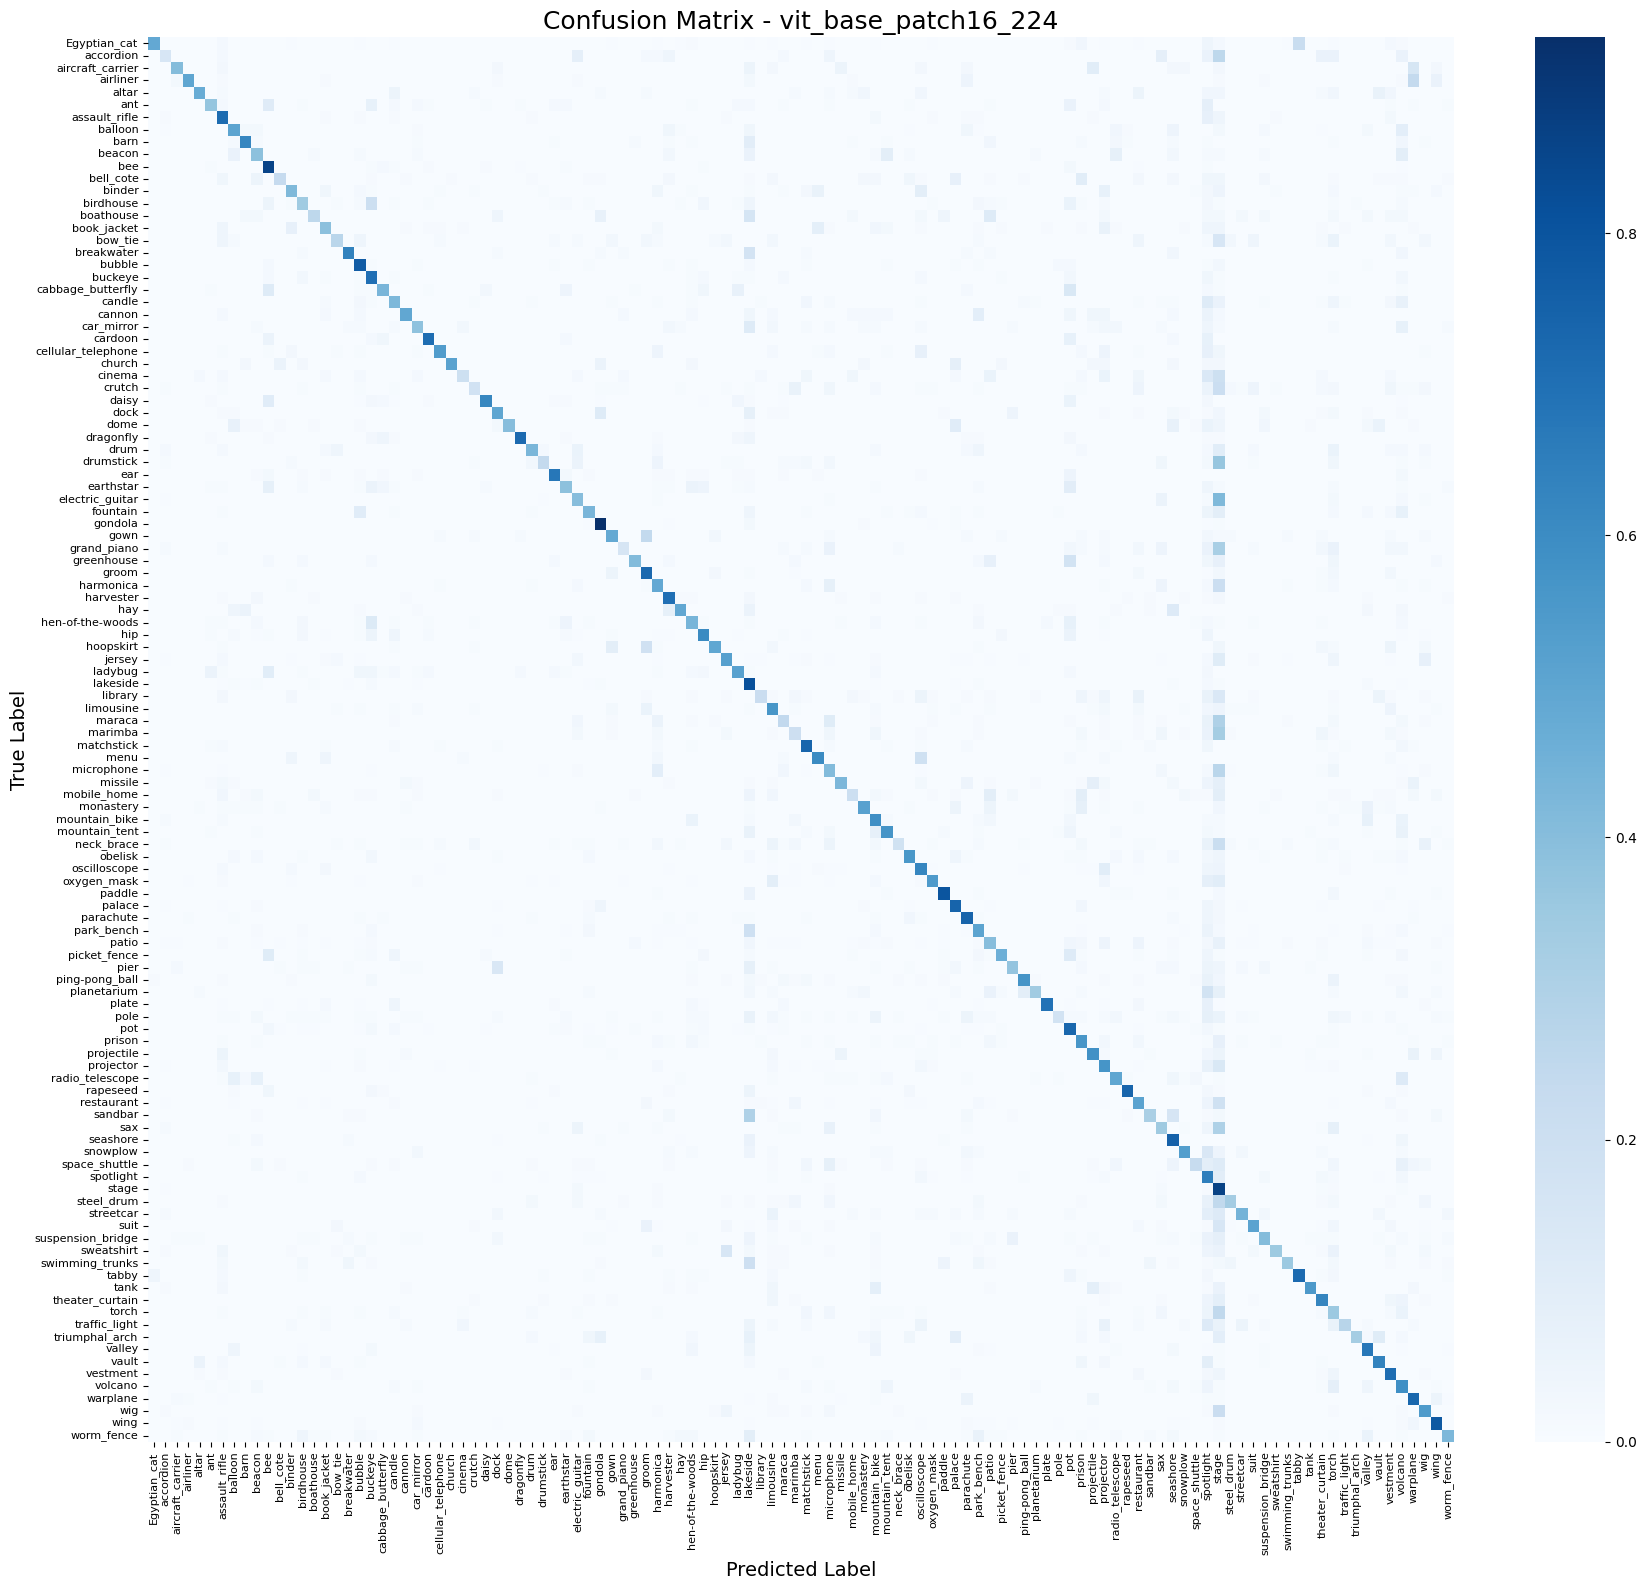


✨ Modell: inception_v3


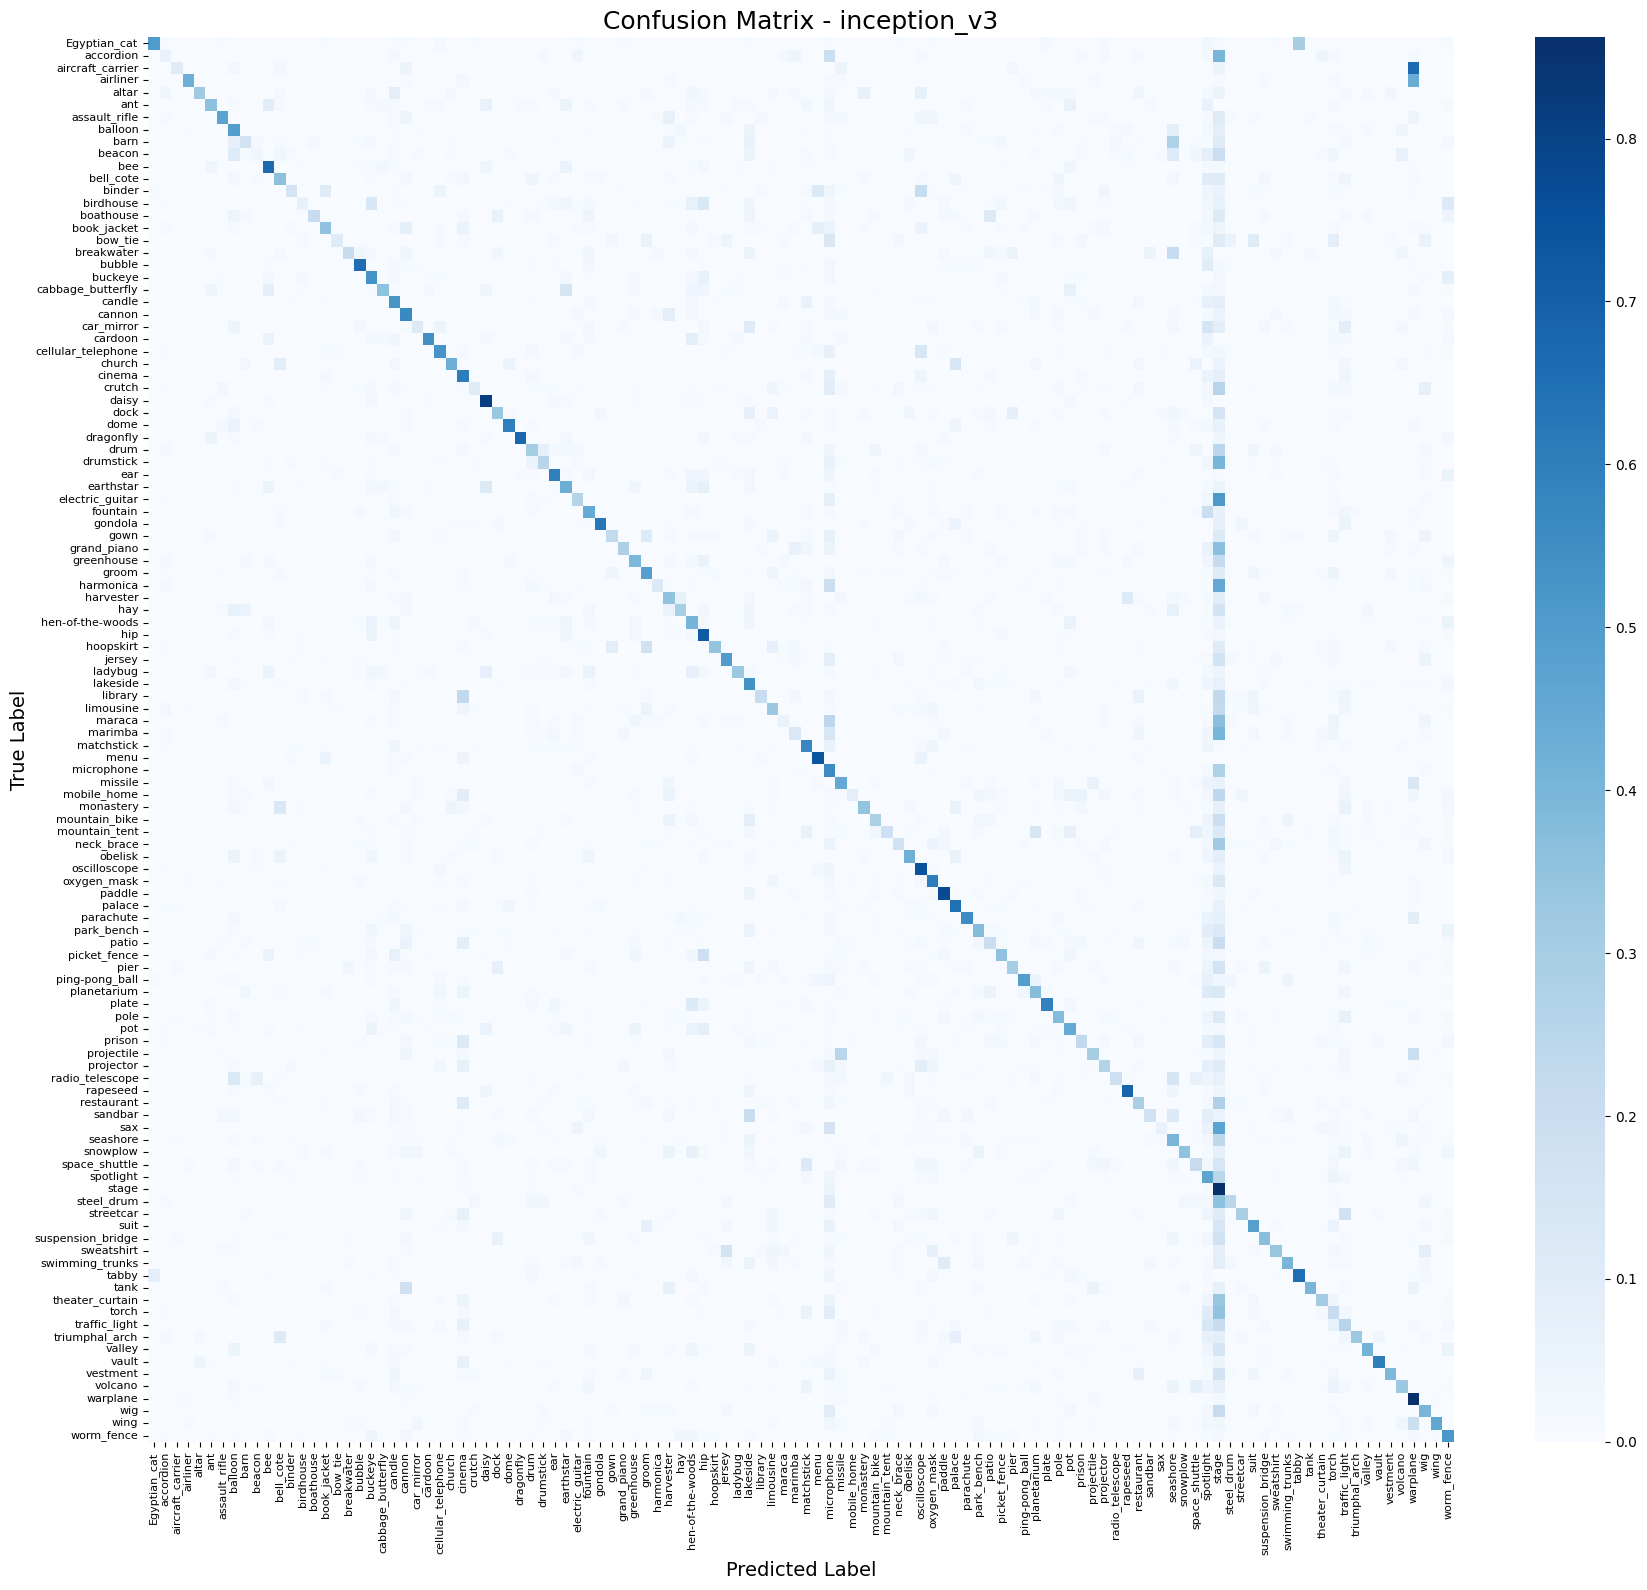

In [ ]:
# Telepítés
!pip install -q timm tqdm

# Könyvtárak importálása
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import timm
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Confusion matrix rajzoló függvény
def plot_confusion_matrix_pretty(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(18, 16))
    sns.heatmap(cm, annot=False, cmap='Blues', cbar=True,
                xticklabels=class_names, yticklabels=class_names)

    plt.title(title, fontsize=18)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()

# GPU használat beállítása
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Eszköz:", device)

# Modellnevek és fájlnevek
model_info = {
    "resnet50": "/content/resnet50_finetuned_114.pt",
    "densenet121": "/content/densenet121_finetuned_114.pt",
    "efficientnet_b0": "/content/efficientnetb0_finetuned_114.pt",
    "convnext_tiny": "/content/convnext_tiny_finetuned_114.pt",
    "vit_base_patch16_224": "/content/vit_b16_finetuned_114.pt",
    "inception_v3": "/content/inception_v3_finetuned_114.pt"
}

# Tesztadat betöltése
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder("/content/imagenet_splitted_db/test", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)
class_names = test_dataset.classes
num_classes = len(class_names)
print(f"\U0001F4DA Kategóriák száma: {num_classes}")

# Betöltési függvény egyéni FC résszel

def load_model(name, path):
    # EfficientNet-B0 kompatibilis név
    if name == "efficientnet_b0":
        name = "efficientnet_b0"  # expliciten nevezve, elkerülve a timm és torch.models keveredést
    model = timm.create_model(name, pretrained=False, num_classes=num_classes)
    model.to(device)
    state_dict = torch.load(path, map_location=device)
    model.load_state_dict(state_dict, strict=False)  # nem dob hibát a nem illeszkedő kulcsok miatt
    model.eval()
    return model

# Modelltesztelő függvény progress bar-ral
def evaluate_model(model, loader):
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Tesztelés", leave=False):
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return y_true, y_pred

# Fő ciklus minden modellhez
for model_name, file_name in model_info.items():
    print(f"\n\u2728 Modell: {model_name}")
    model_path = os.path.join("models", file_name)
    model = load_model(model_name, model_path)
    y_true, y_pred = evaluate_model(model, test_loader)
    plot_confusion_matrix_pretty(y_true, y_pred, class_names, title=f"Confusion Matrix - {model_name}")


✨ EfficientNet-B0 (torchvision) külön tesztelése


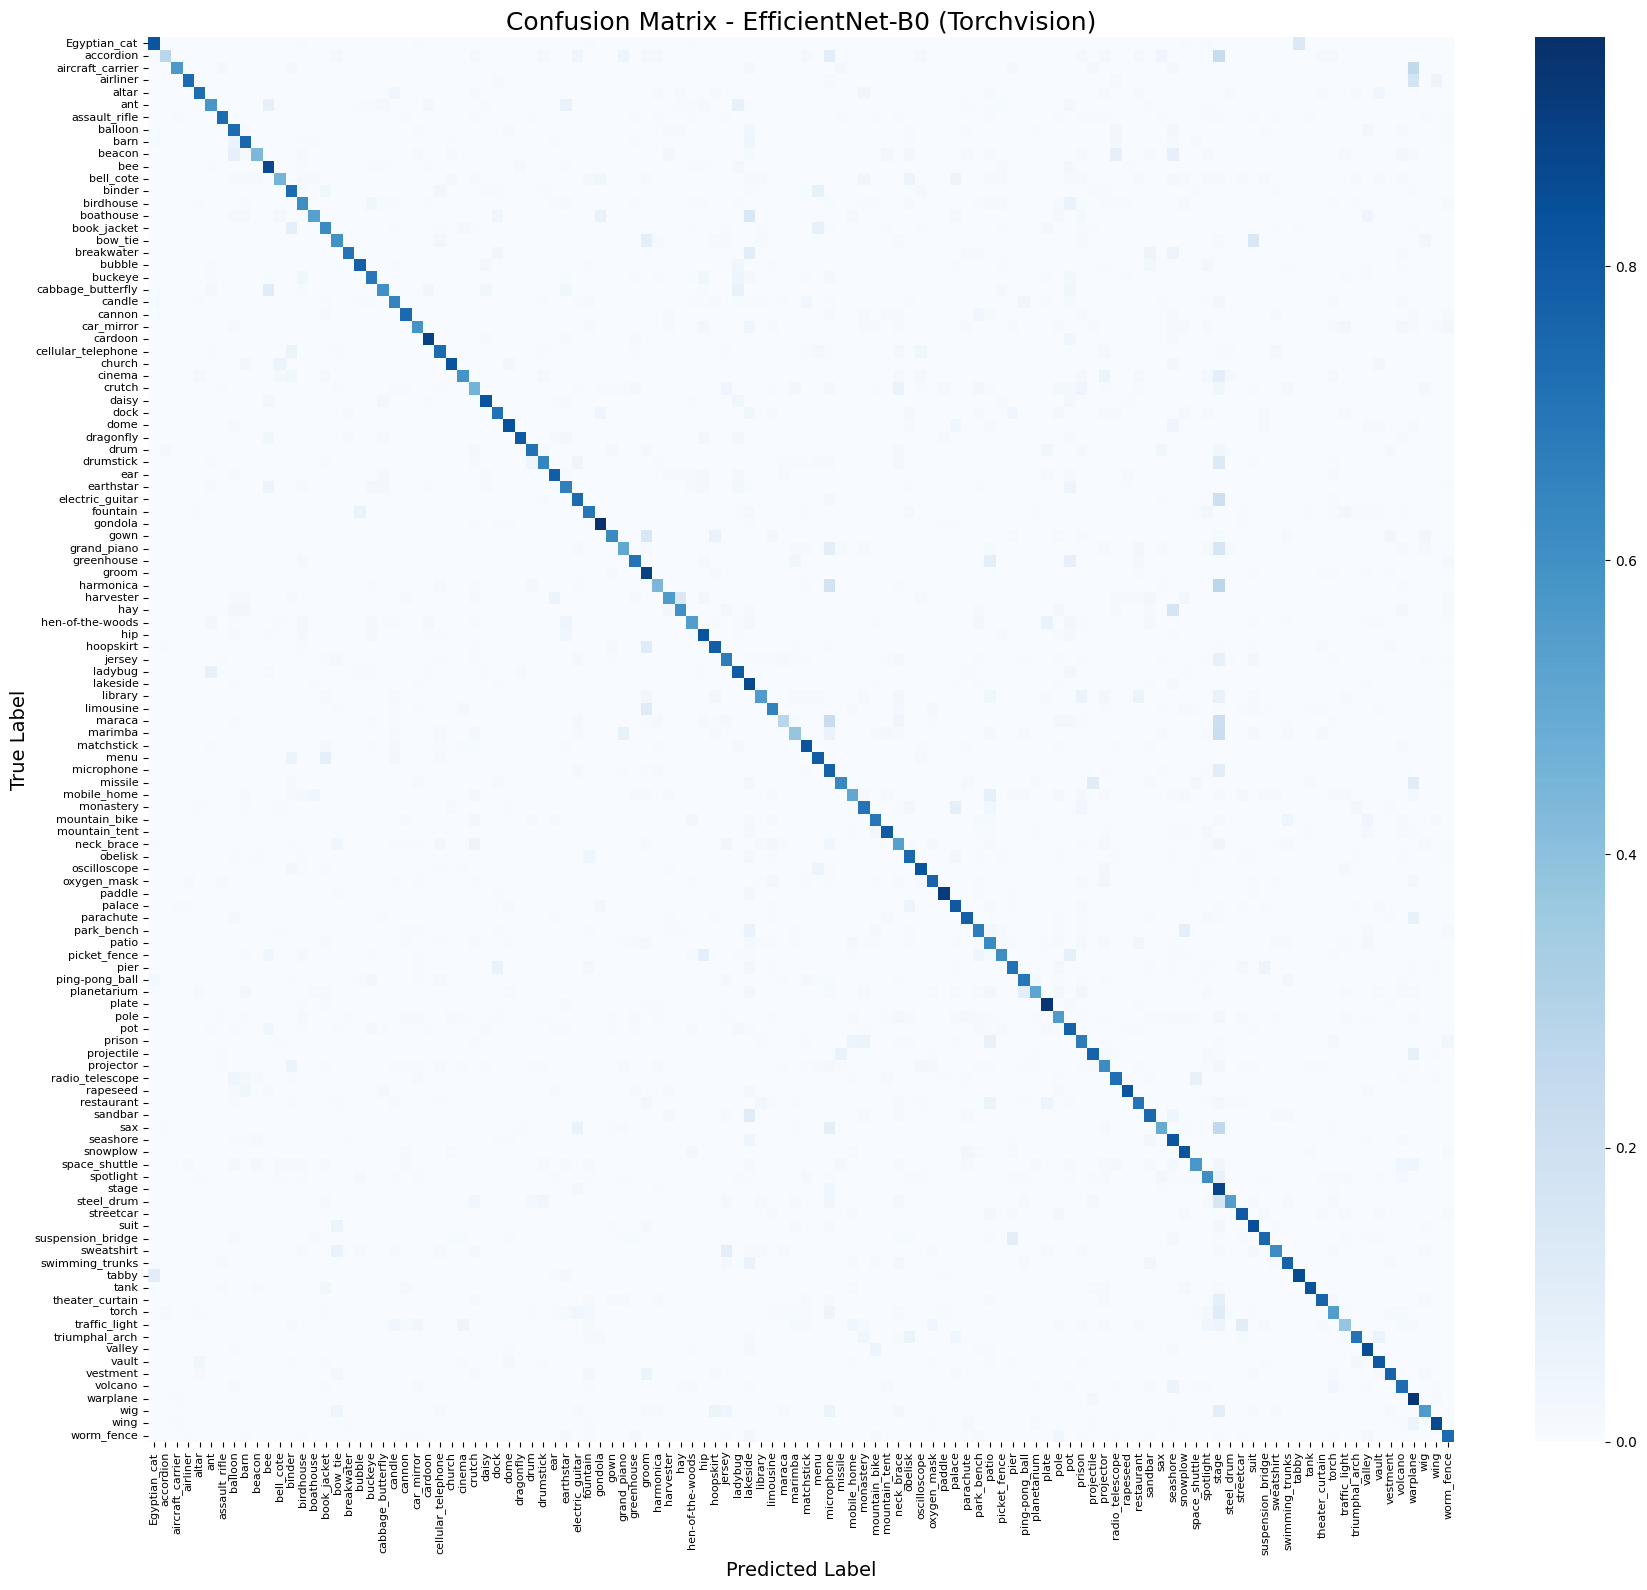

In [ ]:
# 🔧 EfficientNet-B0 (torchvision verzió) külön tesztelése

from torchvision import models

def load_torchvision_efficientnet_b0_finetuned(path, num_classes):
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    model.load_state_dict(torch.load(path, map_location=device))
    model = model.to(device)
    model.eval()
    return model

# Betöltés
print("✨ EfficientNet-B0 (torchvision) külön tesztelése")
efficientnet_path = "/content/efficientnetb0_finetuned_114.pt"
effnet_tv_model = load_torchvision_efficientnet_b0_finetuned(efficientnet_path, num_classes)

# Kiértékelés
y_true, y_pred = evaluate_model(effnet_tv_model, test_loader)
plot_confusion_matrix_pretty(y_true, y_pred, class_names, title="Confusion Matrix - EfficientNet-B0 (Torchvision)")


Üres modellek mátrixai


✨ Modell: resnet50


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 222MB/s]


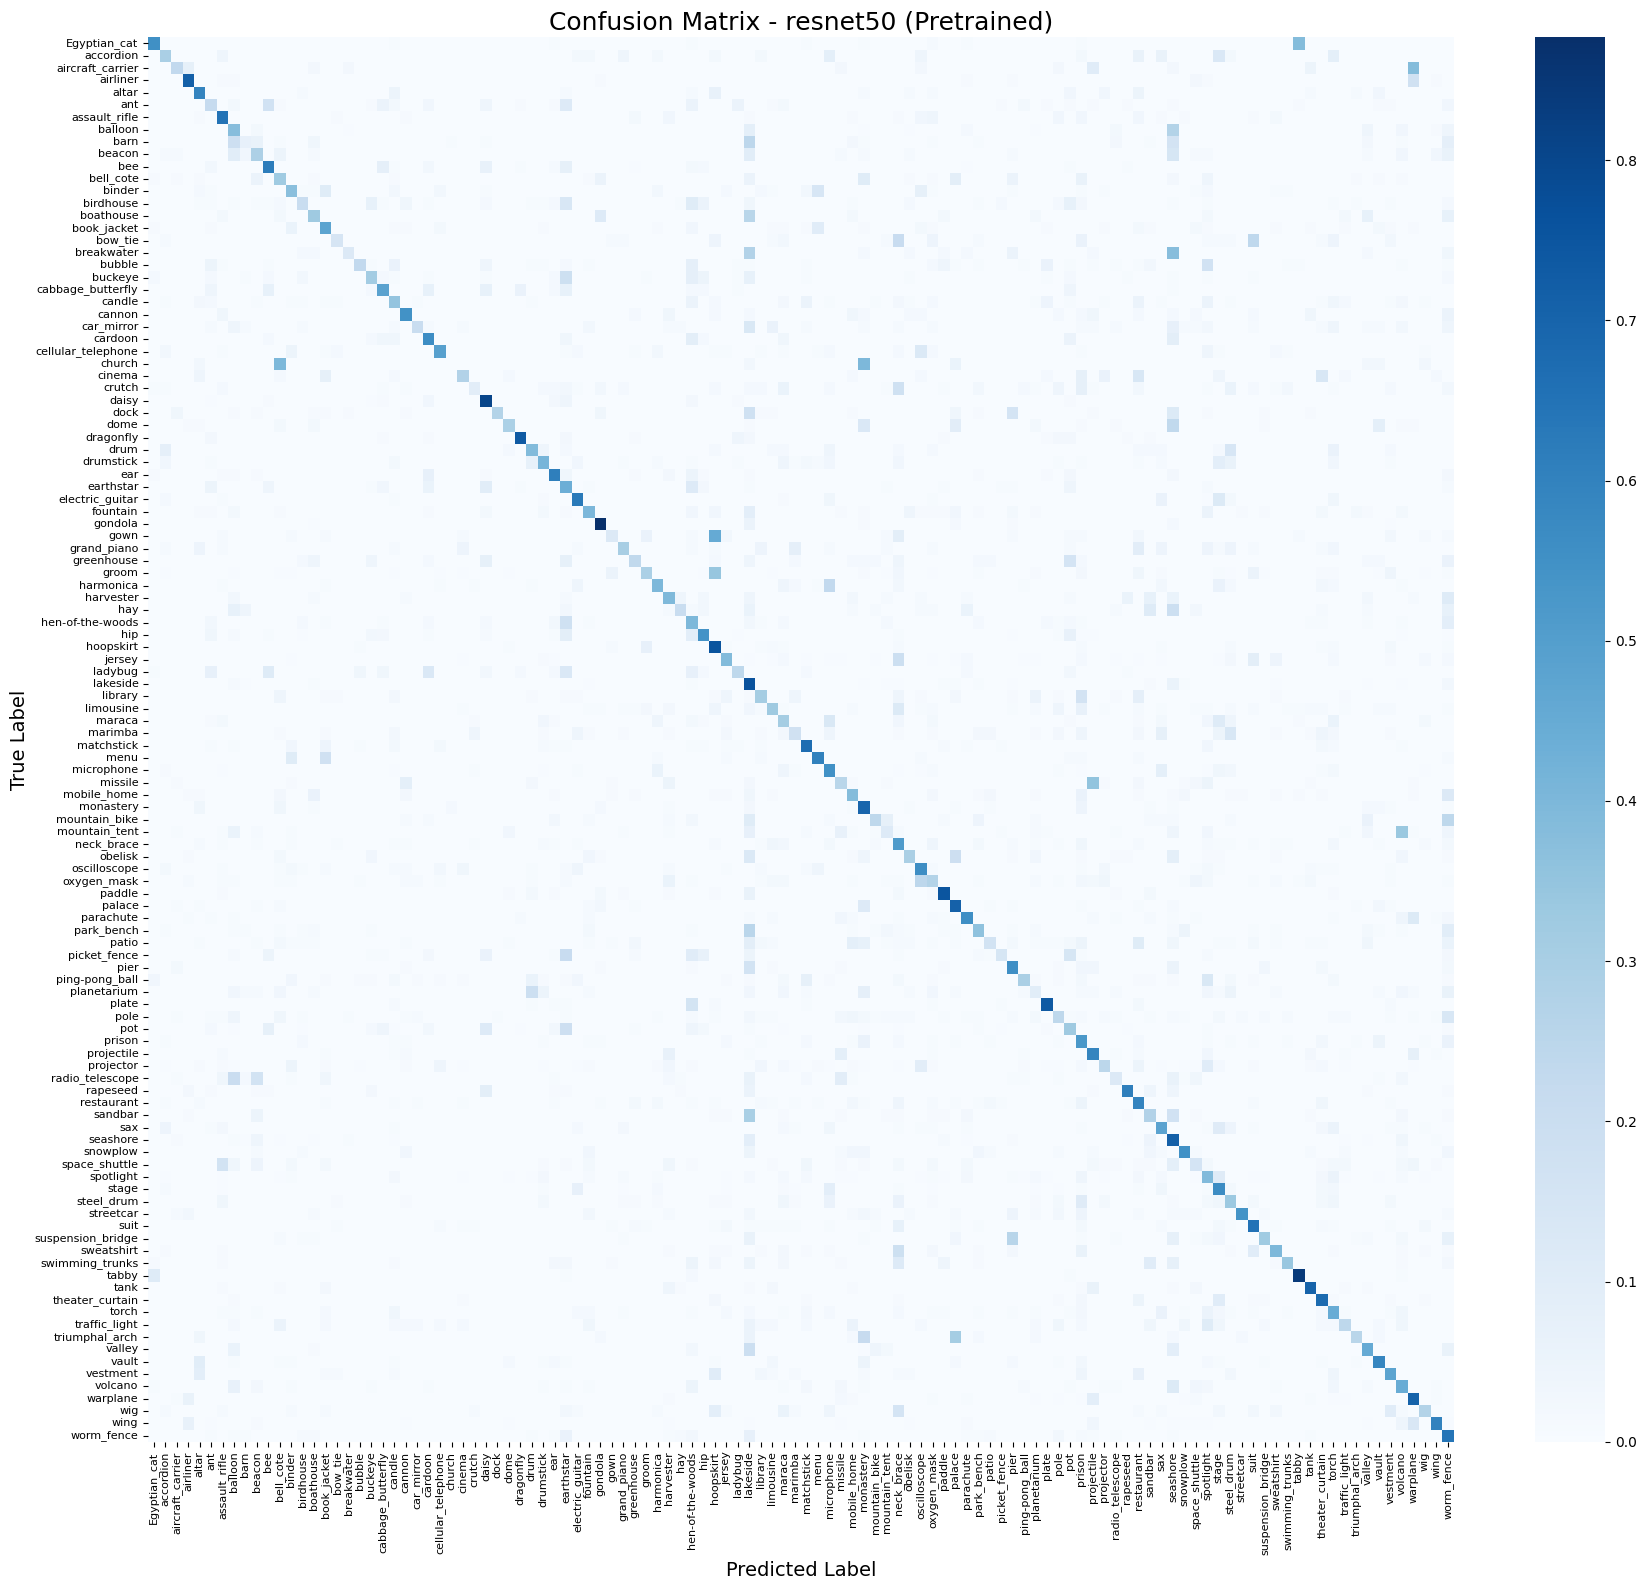


✨ Modell: densenet121


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 226MB/s]


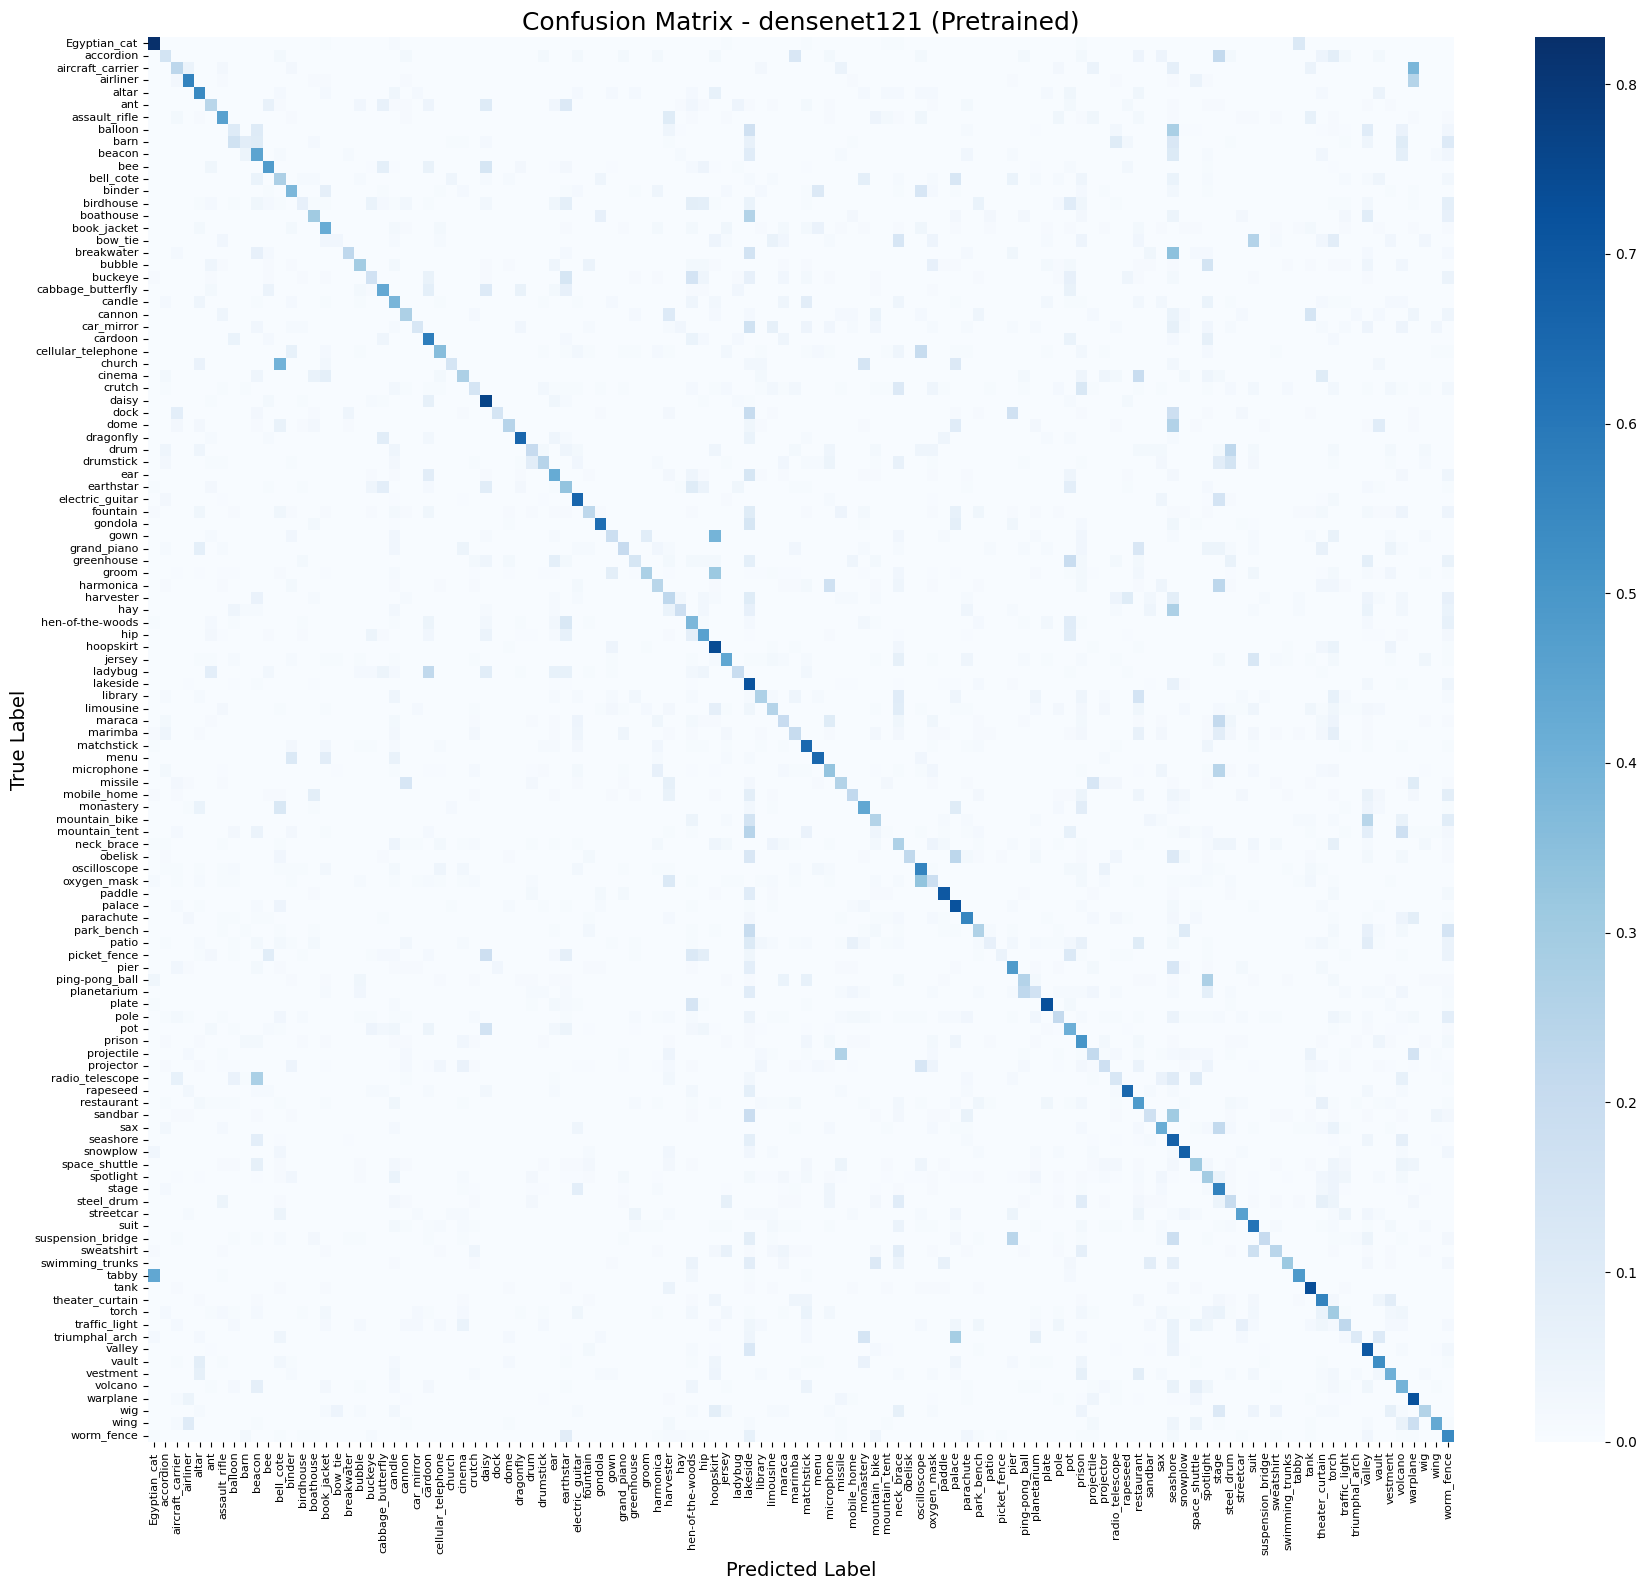

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth



✨ Modell: efficientnet_b0


100%|██████████| 20.5M/20.5M [00:00<00:00, 184MB/s]


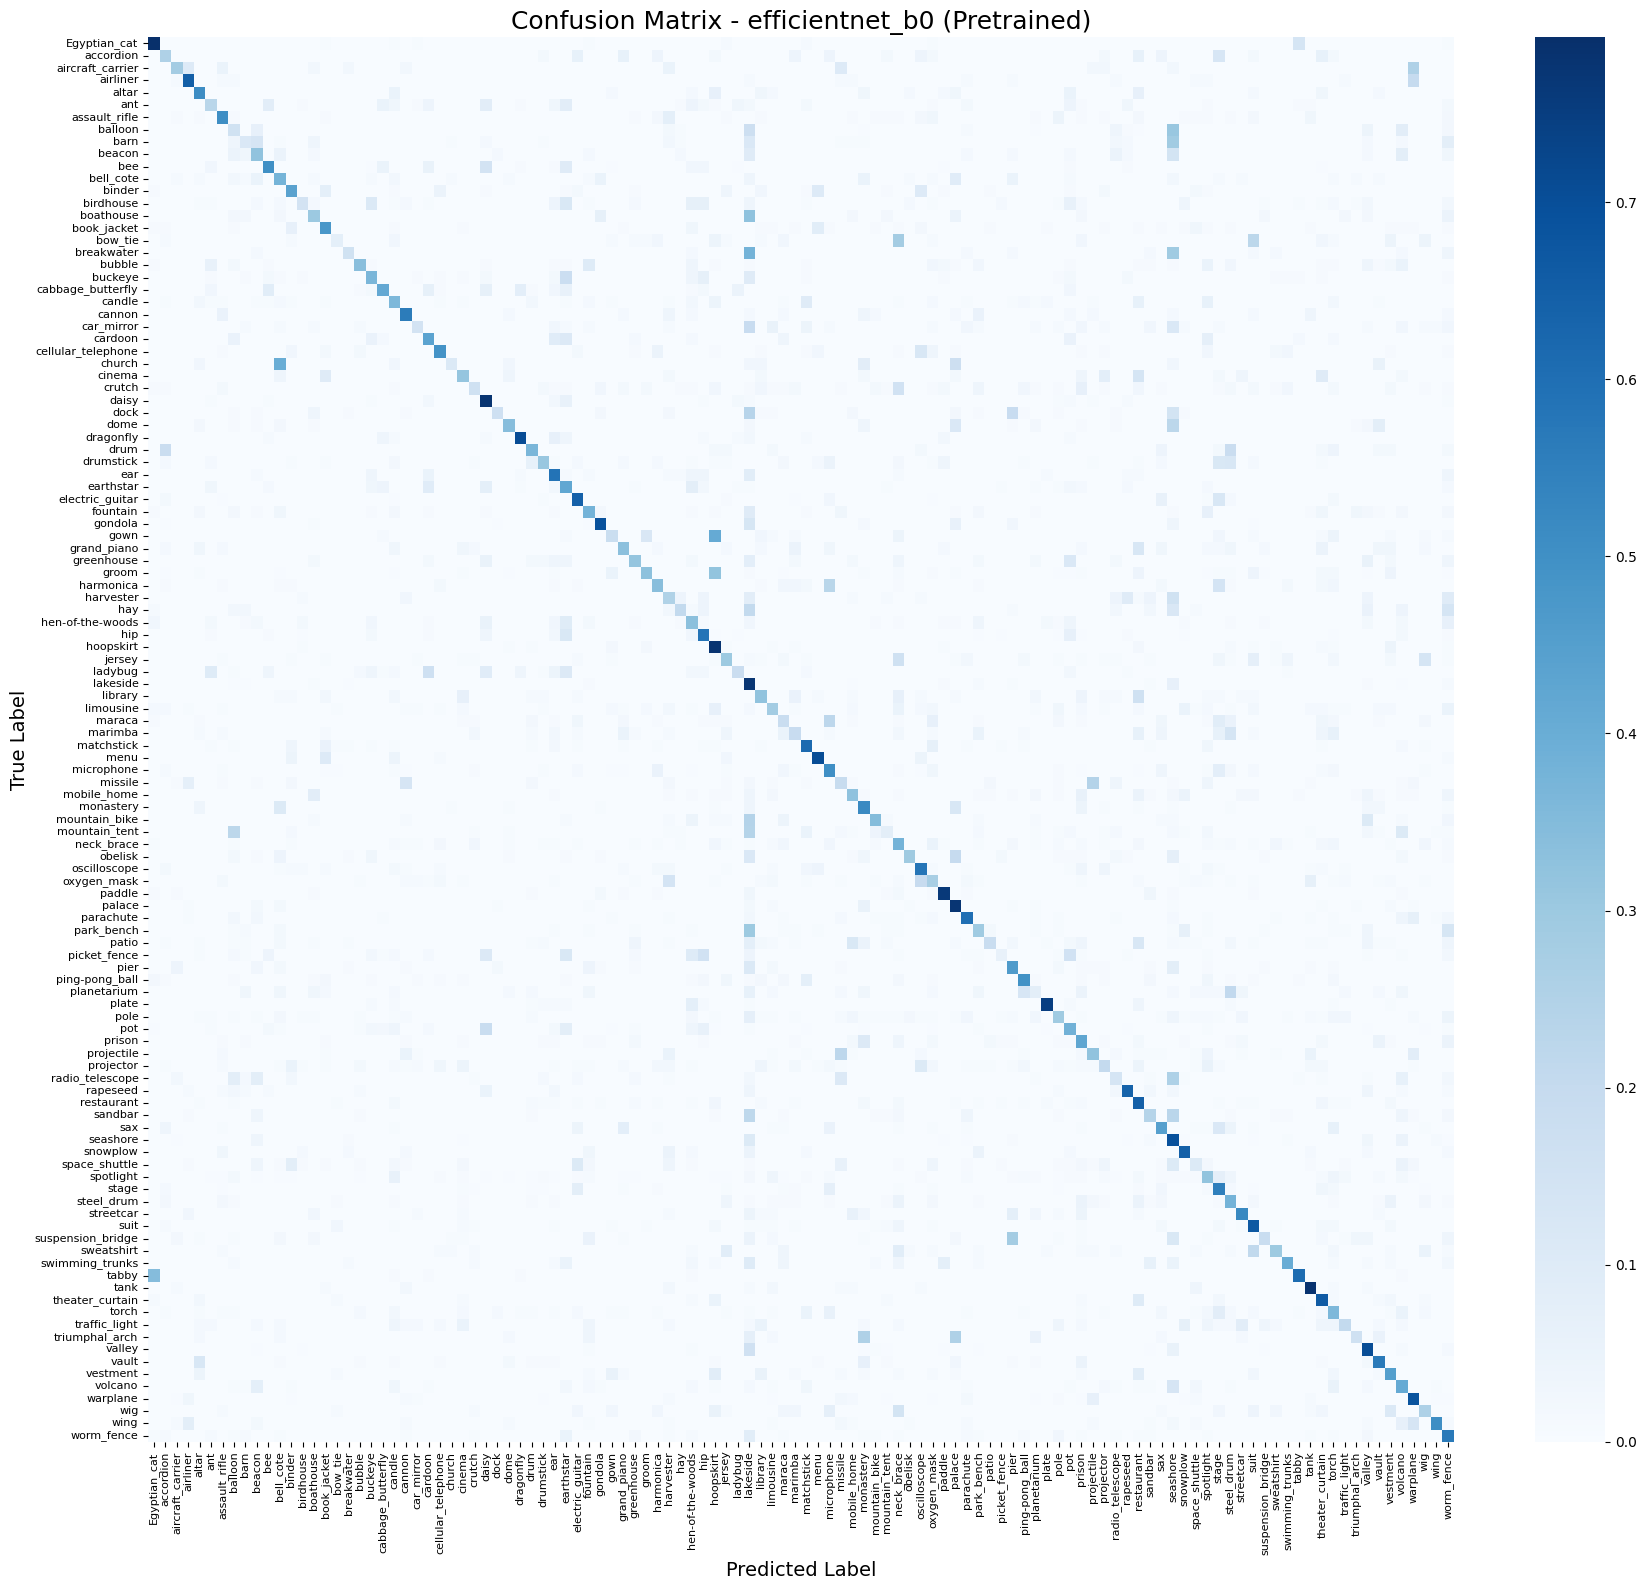


✨ Modell: convnext_tiny


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:00<00:00, 233MB/s] 


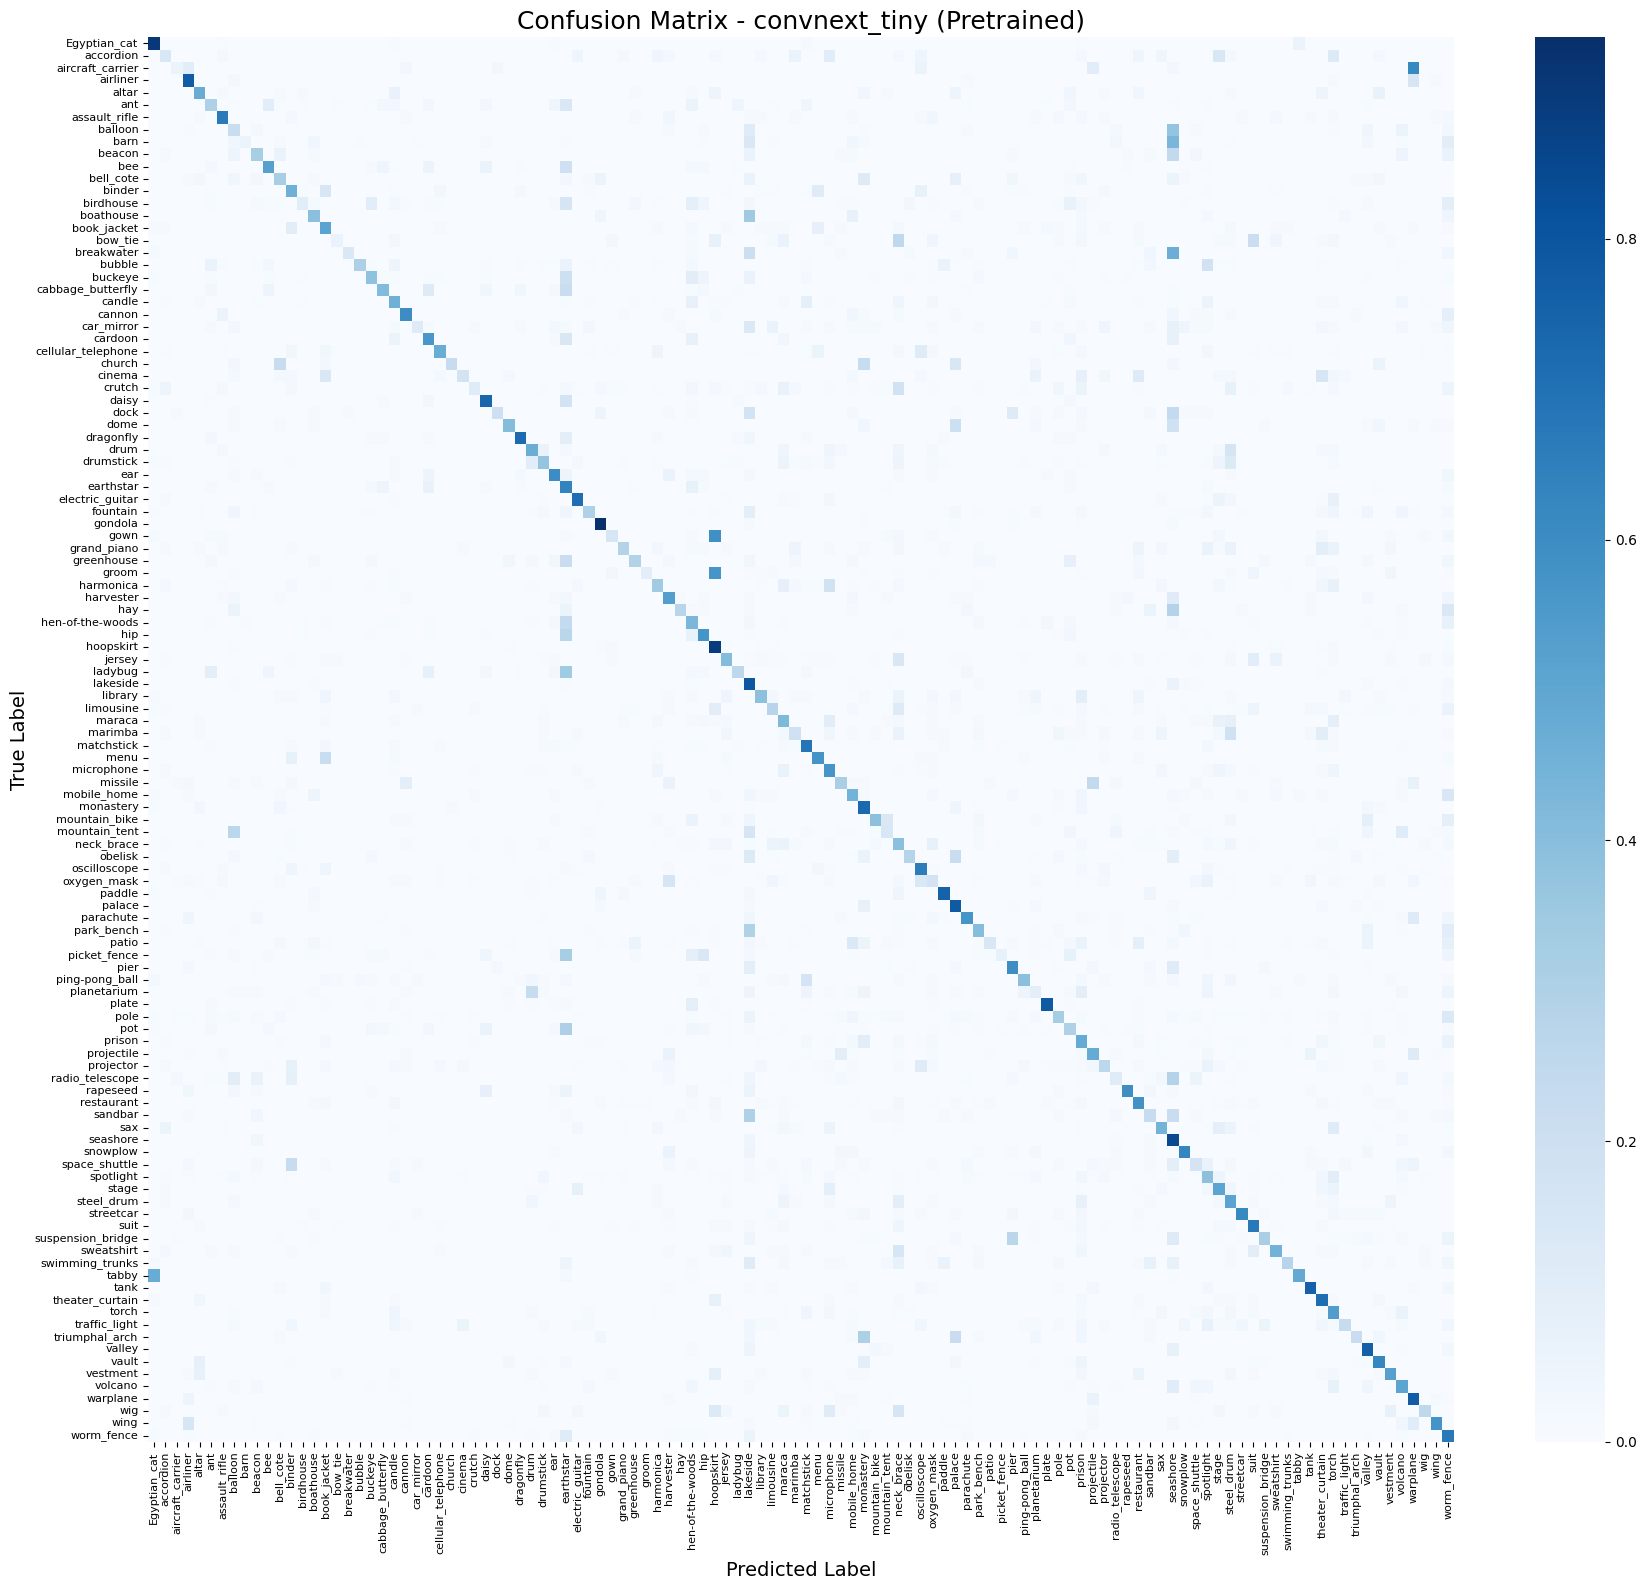


✨ Modell: vit_b_16


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:01<00:00, 233MB/s]


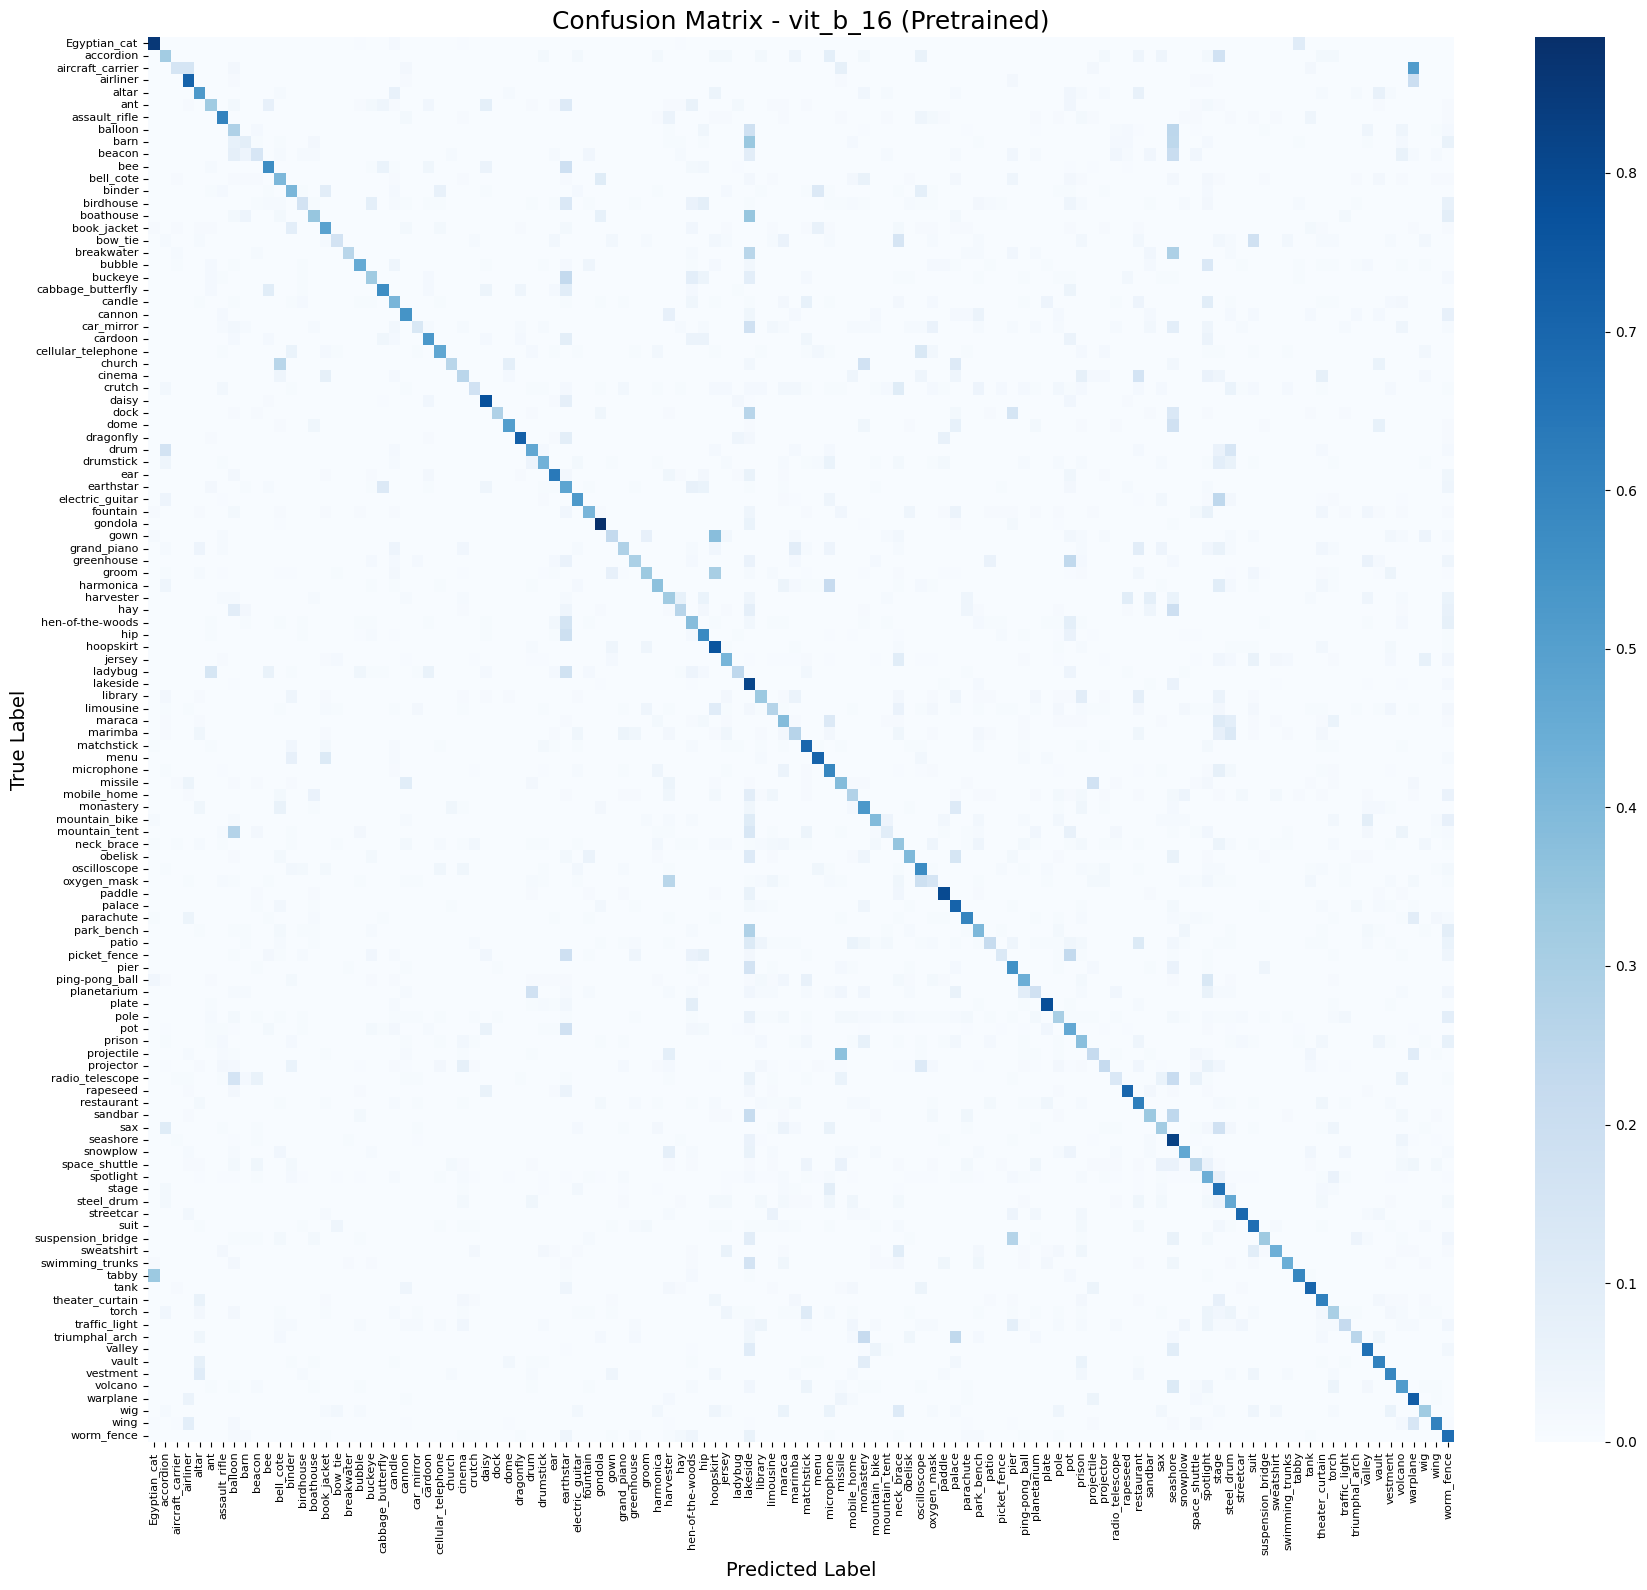


✨ Modell: inception_v3


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 230MB/s] 


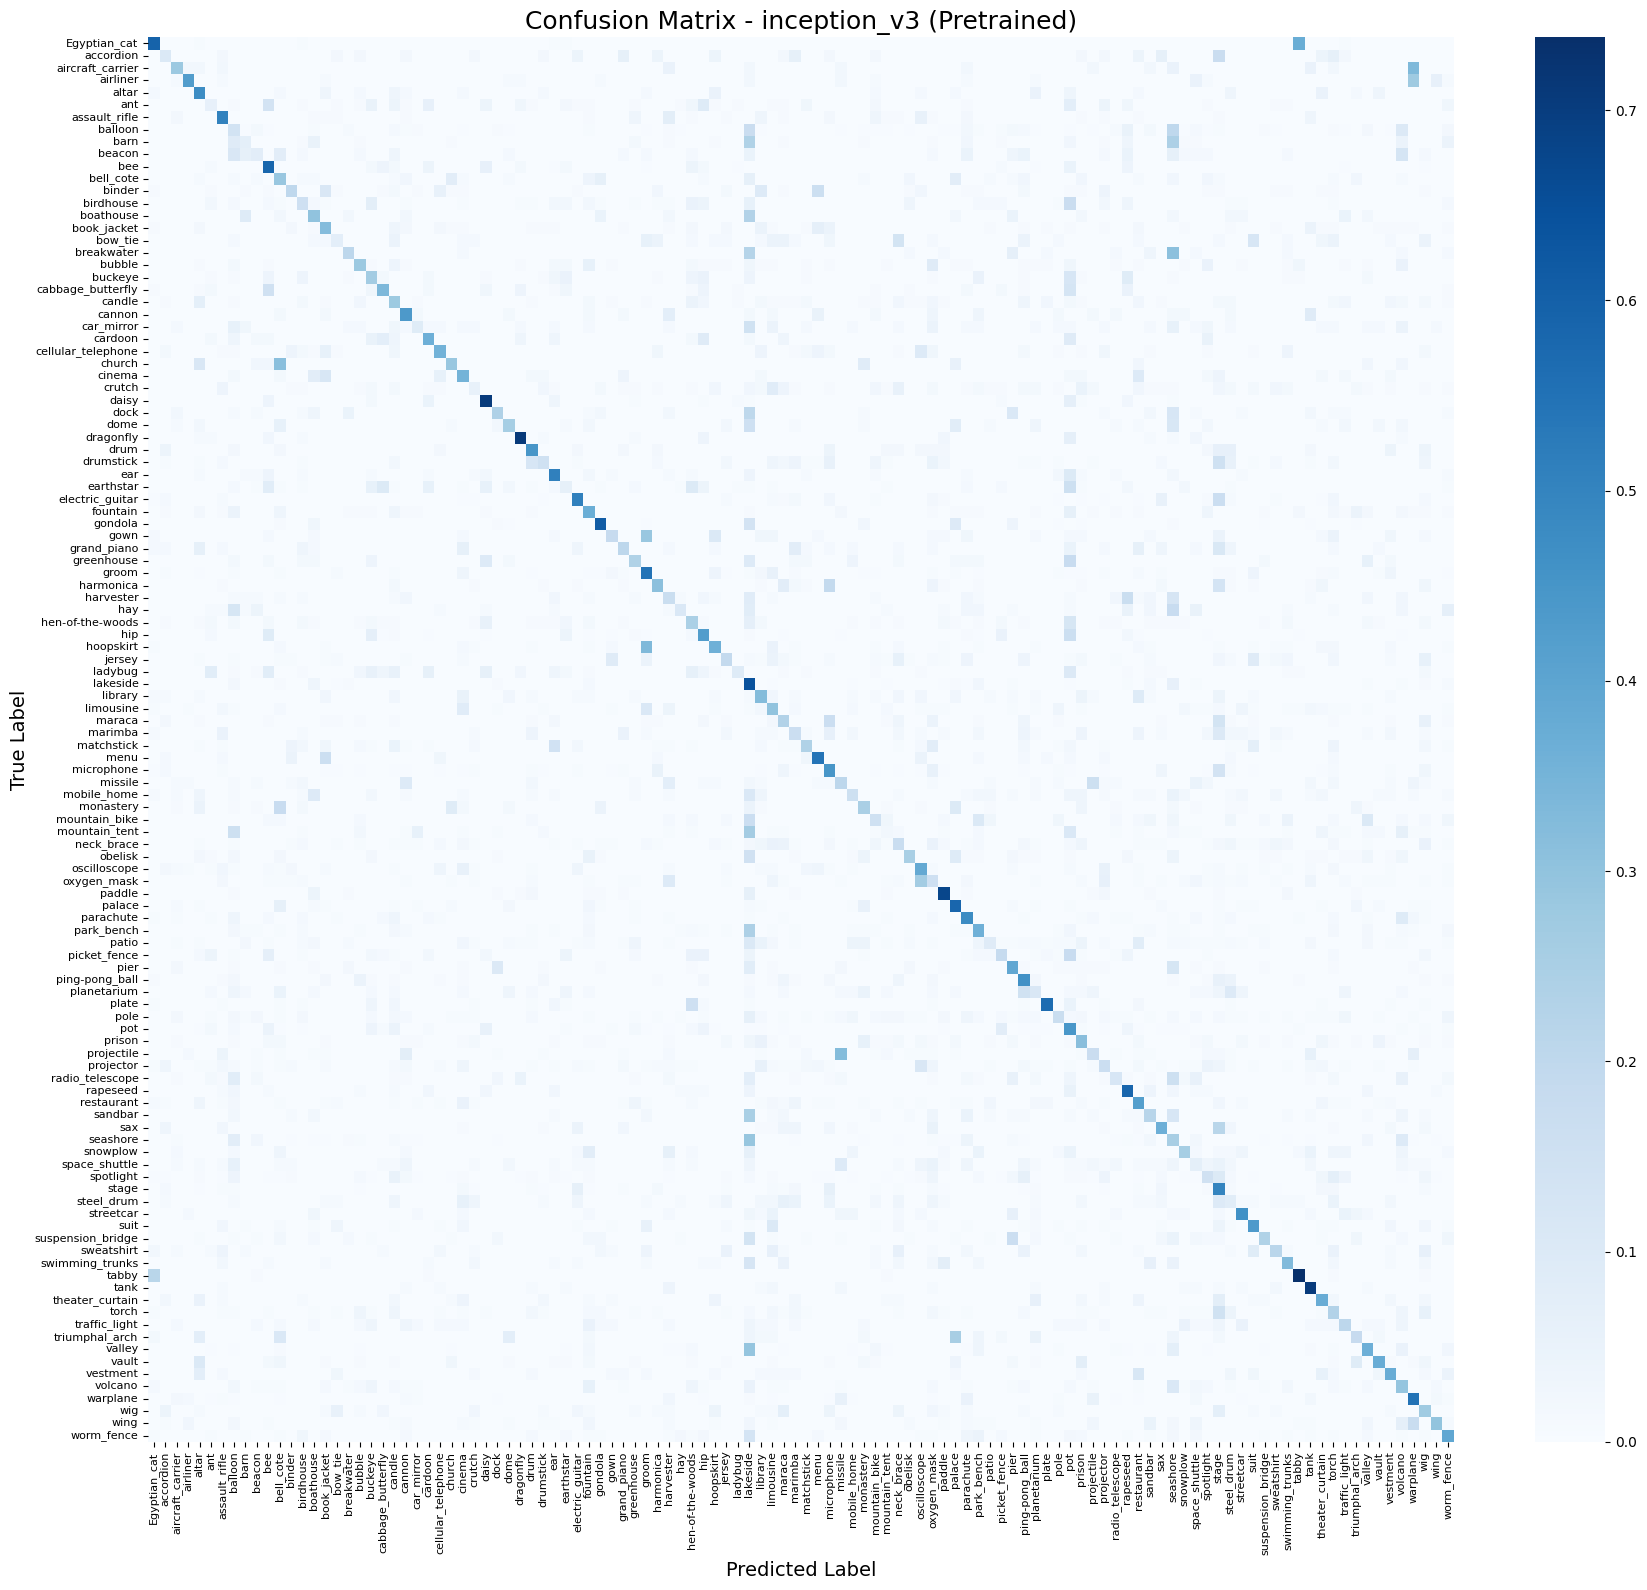

In [ ]:
# 🔍 ImageNet1k-alapú tesztelés gyári súlyokkal

import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from tqdm import tqdm

# --- Paraméterek ---
batch_size = 64
num_workers = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_dir = "/content/imagenet_splitted_db/test"

# --- Transzformáció ---
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Adathalmaz betöltése ---
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
class_names = test_dataset.classes
num_classes = len(class_names)

# --- ImageNet kategória megfeleltetés ---
from torchvision.models import ResNet50_Weights
weights_meta = ResNet50_Weights.DEFAULT.meta
imagenet_categories = weights_meta["categories"]
imagenet_name_to_index = {name.lower(): idx for idx, name in enumerate(imagenet_categories)}
normalized_class_names = [name.replace("_", " ").lower() for name in class_names]

# Ellenőrzés
missing = [name for name in normalized_class_names if name not in imagenet_name_to_index]
if missing:
    print("⚠️ Hiányzó kategóriák az ImageNet1k-ben:")
    for m in missing:
        print(f" - {m}")
    raise ValueError("A fenti kategóriák nem szerepelnek az ImageNet-1k-ben!")

imagenet_indices = [imagenet_name_to_index[name] for name in normalized_class_names]

# --- Confusion Matrix rajzoló függvény ---
def plot_confusion_matrix_pretty(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(18, 16))
    sns.heatmap(cm, annot=False, cmap='Blues', cbar=True,
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=18)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()

# --- Modellnevek listája ---
model_fns = [
    models.resnet50,
    models.densenet121,
    models.efficientnet_b0,
    models.convnext_tiny,
    models.vit_b_16,
    models.inception_v3
]
model_names = [
    "resnet50", "densenet121", "efficientnet_b0",
    "convnext_tiny", "vit_b_16", "inception_v3"
]

# --- Fő ciklus ---
for model_fn, model_name in zip(model_fns, model_names):
    print(f"\n\u2728 Modell: {model_name}")
    model = model_fn(weights="DEFAULT")
    model = model.to(device)
    model.eval()

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f"{model_name} tesztelés", leave=False):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    y_probs = np.array(all_probs)
    y_true = np.array(all_labels)
    y_probs_subset = y_probs[:, imagenet_indices]
    y_pred = np.argmax(y_probs_subset, axis=1)

    plot_confusion_matrix_pretty(y_true, y_pred, class_names, title=f"Confusion Matrix - {model_name} (Pretrained)")
